In [1]:
import seaborn as sns
import os
from scipy.stats import kurtosis, skew
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from rcv_distribution import *
from MDS_analysis import *
from voting_rules import *
import random
from itertools import permutations
from collections import defaultdict
from collections import Counter

c:\Users\mahsh\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\mahsh\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
c:\Users\mahsh\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def normalize_data(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [3]:
df = pd.read_csv("election_table.csv")

In [ ]:
directory = "np_data_new"
files = sorted(Path(directory).glob("*.npy"))
normalized_chunks_all = []
normalized_chunks_local = []
normalized_chunks_state = []
normalized_chunks_federal = []

for f in os.listdir(directory):
    
    file = os.path.join(directory, f)
    
    dist = np.load(file)
    dist = normalize_data(dist)
    normalized_chunks_all.append(dist)

    # level specific arrays
    filename = f[0:-4] + '.csv'
    level = df.loc[df["filename"]==filename, "level"]
    #print(level)
    if level == 'LOCAL':
        normalized_chunks_local.append(dist)
    elif level == 'FEDERAL':
        normalized_chunks_federal.append(dist)
    elif level == 'STATE':
        normalized_chunks_state.append(dist)


all_dist = np.concatenate(normalized_chunks_all) if normalized_chunks_all else np.array([], dtype=float)
local_dist = np.concatenate(normalized_chunks_local) if normalized_chunks_local else np.array([], dtype=float)
state_dist = np.concatenate(normalized_chunks_state) if normalized_chunks_state else np.array([], dtype=float)
federal_dist = np.concatenate(normalized_chunks_federal) if normalized_chunks_federal else np.array([], dtype=float)

print(f"Loaded {len(files)} files → combined length: {all_dist.size}")
# Optional: save it
# np.save("combined_distribution.npy", big_array)


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [5]:
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde

C:\Users\mahsh\AppData\Local\Temp\ipykernel_9452\2259756928.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


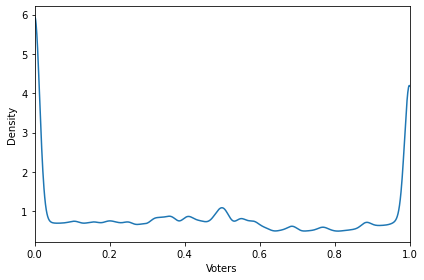

In [18]:
grid = np.linspace(0, 1, 1000)

kde = gaussian_kde(all_dist, bw_method='scott')
#kde.set_bandwidth(bw_method=kde.factor * 1.0)
kde = kde(grid)


fig, ax = plt.subplots(figsize=(6,4))
ax.plot(grid, kde, linewidth=1.5)

ax.set_xlabel("Voters")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
#ax.set_title("Average KDE by Level")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
grid = np.linspace(0, 1, 1000)

kde = gaussian_kde(local_dist)
kde.set_bandwidth(bw_method=kde.factor * 1.0)
kde = kde(grid)


fig, ax = plt.subplots(figsize=(6,4))
ax.plot(grid, kde, linewidth=1.5)

ax.set_xlabel("Voters")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
#ax.set_title("Average KDE by Level")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
from scipy.stats import gaussian_kde

data = np.asarray(all_dist, dtype=float)
data = data[np.isfinite(data)]

# (optional) subsample for fitting if data is huge
n_fit = min(200_000, data.size)
rng = np.random.default_rng(0)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]

kde = gaussian_kde(fit, bw_method='scott')

# evaluate on a modest grid, then interpolate back to data points
xmin, xmax = data.min(), data.max()
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = kde(x_grid)
densities = np.interp(data, x_grid, y_grid)   # fast: O(n + G)


In [20]:
irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, condorcet, irv, plurality = top_n_gamma(4, all_dist, densities, kde, (all_dist, densities), visualize=False)

In [21]:
print(irv_winner)
print(plurality_winner)
print(condorcet_winner)

0.6662389801124518
0.11185174148141133
0.37127351121616975


Testing

In [2]:
import os, random
from pathlib import Path
from collections import defaultdict
from itertools import permutations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from simulation import*

c:\Users\mahsh\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\mahsh\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
c:\Users\mahsh\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Loading Distributions

In [3]:
df = pd.read_csv("election_table.csv")

directory = "np_data_new"
normalized_chunks_all, normalized_chunks_local = [], []
normalized_chunks_state, normalized_chunks_federal = [], []

normalized_chunks_partisan = []
normalized_chunks_non_partisan, normalized_chunks_primary = [], []

# ensure df has clean keys
df = df.copy()
df["filename"] = df["filename"].astype(str).str.strip()
df["level"]    = df["level"].astype(str).str.strip().str.upper()
level_map = df.set_index("filename")["level"].to_dict()

df2 = df.copy()
df2["filename"] = df2["filename"].astype(str).str.strip()
df2["partisan"]    = df2["partisan"].astype(str).str.strip().str.upper()
partisan_map = df2.set_index("filename")["partisan"].to_dict()

files = sorted(Path(directory).glob("*.npy"))
for fpath in files:
    dist = normalize_data(np.load(fpath, allow_pickle=False))
    if dist.size == 0:
        continue
    normalized_chunks_all.append(dist)

    fname_csv = fpath.with_suffix(".csv").name
    level = level_map.get(fname_csv)
    p = partisan_map.get(fname_csv)
    

    if level == "LOCAL":
        normalized_chunks_local.append(dist)
    elif level == "STATE":
        normalized_chunks_state.append(dist)
    elif level == "FEDERAL":
        normalized_chunks_federal.append(dist)
    
    if p == "YES":
        normalized_chunks_partisan.append(dist)
    elif p == "NO":
        normalized_chunks_non_partisan.append(dist)
    else:
        normalized_chunks_primary.append(dist)

all_dist     = np.concatenate(normalized_chunks_all)     if normalized_chunks_all     else np.array([], float)
local_dist   = np.concatenate(normalized_chunks_local)   if normalized_chunks_local   else np.array([], float)
state_dist   = np.concatenate(normalized_chunks_state)   if normalized_chunks_state   else np.array([], float)
federal_dist = np.concatenate(normalized_chunks_federal) if normalized_chunks_federal else np.array([], float)

partisan_dist   = np.concatenate(normalized_chunks_partisan)   if normalized_chunks_partisan   else np.array([], float)
non_partisan_dist   = np.concatenate(normalized_chunks_non_partisan)   if normalized_chunks_non_partisan   else np.array([], float)
primary_dist = np.concatenate(normalized_chunks_primary) if normalized_chunks_primary else np.array([], float)

print(f"Loaded {len(files)} files → combined length: {all_dist.size}")
print(f"Loaded {len(files)} primaryfiles → combined length: {primary_dist.size}")


Loaded 503 files → combined length: 17154841
Loaded 503 primaryfiles → combined length: 3831814


Running 1000 Simulations

_Local Distribution_

0


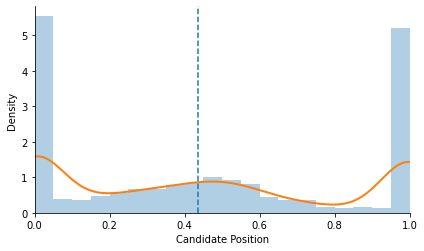

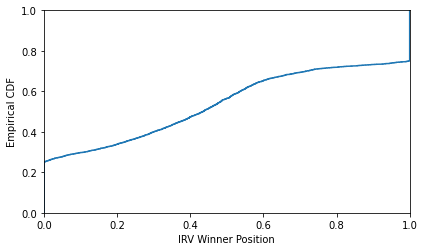

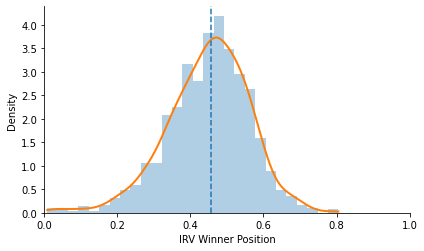

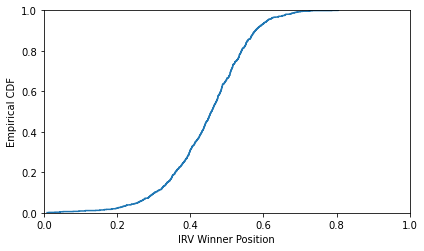

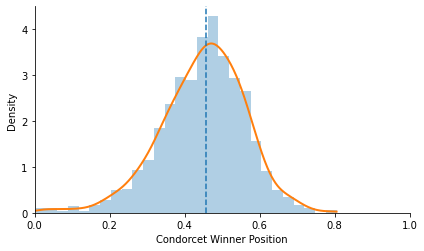

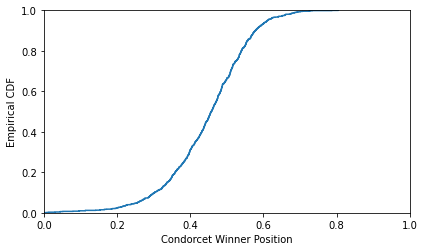

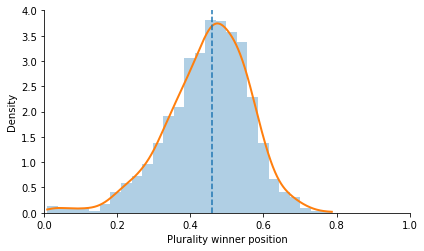

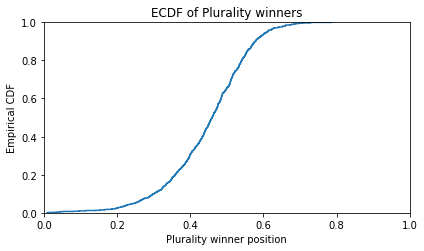

1
42
42


In [ ]:
data = np.asarray(local_dist, float)
data = data[np.isfinite(data)]
rng = np.random.default_rng(0)
n_fit = min(200_000, data.size)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)          # for plotting only

# CANDIDATE DIST = UNIFORM on [xmin, xmax]
x_can = np.linspace(xmin, xmax, 2048)  # evenly spaced!
y_can = np.ones_like(x_can)            # flat → uniform after normalization
candidate_dist = (x_can, y_can)


#candidate_dist = (x_grid, y_grid)

N_SIM = 10000
N_CANDIDATES = 4

irv_winners = []
condorcet_winners = []
plurality_winners = []
simulated_candidates = []
irv_condorcet_differences = 0
plurality_condorcet_differences = 0
irv_plurality_differences = 0
c = 0
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, median_voter, median_voter_preference, condorcet, irv, plurality = \
        top_n_gamma(
            N_CANDIDATES,
            x_voter_plot=x_grid,
            y_voter_plot=y_grid,
            voter_dist=voter_kde,           # <-- KDE object so .resample works
            candidate_dist=candidate_dist,
            visualize=False
        )
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))

    if irv_winner != condorcet_winner:
        irv_condorcet_differences += 1
    if irv_winner != plurality_winner:
        irv_plurality_differences += 1
    if plurality_winner != condorcet_winner:
        plurality_condorcet_differences += 1

    simulated_candidates.extend(top_n_points)

    if (c % 100 == 0):
        print(c)
    c += 1
    
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)
simulated_candidates = np.asarray(simulated_candidates, float)



#Top n points (candidate distribution)

bins = fd_bins(simulated_candidates)
kde_w = gaussian_kde(simulated_candidates, bw_method='scott')
xx = np.linspace(simulated_candidates.min(), simulated_candidates.max(), 1000)
yy = kde_w(xx)

med = float(np.median(simulated_candidates))
lo, hi = hdi(simulated_candidates, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(simulated_candidates, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Candidate Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(simulated_candidates)
y_ecdf = np.arange(1, simulated_candidates.size + 1) / simulated_candidates.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("IRV Winner Position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
#plt.title("ECDF of IRV winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()

# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(irv_winners)
y_ecdf = np.arange(1, irv_winners.size + 1) / irv_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("IRV Winner Position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
#plt.title("ECDF of IRV winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(condorcet_winners)
y_ecdf = np.arange(1, condorcet_winners.size + 1) / condorcet_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("Condorcet Winner Position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
#plt.title("ECDF of IRV winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()



# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(plurality_winners)
y_ecdf = np.arange(1, plurality_winners.size + 1) / plurality_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("Plurality winner position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("ECDF of Plurality winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()

print(irv_condorcet_differences)
print(plurality_condorcet_differences)
print(irv_plurality_differences)

State Distribution for Voters and Uniform Distribution for Candidates

In [3]:
data = np.asarray(state_dist, float)
data = data[np.isfinite(data)]
rng = np.random.default_rng(0)
n_fit = min(200_000, data.size)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)          # for plotting only

TypeError: top_n_gamma() missing 2 required positional arguments: 'nl_dist_x' and 'nl_dist_y'

In [5]:
print(top_n_points)
print(median_voter)
print(median_voter_preference)
print(abs(median_voter_preference - median_voter))

[0.11333659 0.58622374 1.         0.        ]
0.4652457935878548
0.5862237420615535
0.1209779484736987


In [6]:
print(condorcet_winner)

0.5862237420615535


In [7]:
print(xmin)
print(xmax)

0.0
1.0


In [4]:
# ---- main function (expects voter_kde OR array; candidate_dist is (x, y)) ----
def top_n_gamma(n, x_voter_plot, y_voter_plot, voter_dist, candidate_dist, nl_dist, level, visualize=False):
    x_can, y_can = candidate_dist

    # sample candidate points proportional to candidate density
    probs = np.clip(np.asarray(y_can, float), 0, None)
    probs = probs / probs.sum() if probs.sum() > 0 else np.ones_like(probs) / probs.size
    k = min(10, x_can.size)
    replace = x_can.size < 10

    # gamma -> number of consistent voters (0..1000)
    df_gamma = pd.read_csv("election_table.csv")
    # choosing gamma from same candidate count and level
    mask = (
    df_gamma["candidates"].eq(n) &
    df_gamma["level"].astype(str).str.strip().str.upper().eq(level.strip().upper())
    )
    gamma_vals = df_gamma.loc[mask, "gamma"].to_numpy()

    random_gamma = float(np.random.choice(gamma_vals)) if gamma_vals.size else 0.5
    consistent_voters = int(np.clip(round(random_gamma * 1000), 0, 1000))


    candidate_points = np.random.choice(x_can, size=n, p=probs, replace=replace)
    candidate_points = np.array(list(dict.fromkeys(candidate_points.tolist())))  # de-dup, keep order
    

  
    top_n_points = candidate_points
    
    perms = generate_and_group_permutations(top_n_points, n)
    
    # round 2: consistent voters -> ranked by proximity
    sampled_points = sample_from(voter_dist, consistent_voters, 0.0, 1.0)
    median_voter = np.median(sampled_points)
    idx, median_voter_preference, dis = closest_value(top_n_points, median_voter)
    
    ballot_counts = {}
    for p in sampled_points:
        order = tuple(top_n_points[np.argsort(np.abs(top_n_points - p))])
        order = randomly_chop_order(order)
        ballot_counts[order] = ballot_counts.get(order, 0) + 1
    
    # inconsistent voters -> pick from "inconsistent" permutations bucketed by first choice
    
    for key in list(perms.keys()):
        try:
            # if you have is_consistent(), filter; else keep as-is
            perms[key] = [b for b in perms[key] if not is_consistent(b, {t: t for t in top_n_points})]
        except NameError:
            pass

    inc = 1000 - consistent_voters
    if inc > 0:
        inc_pts = sample_from(nl_dist, inc, 0.0, 1.0)
        for p in inc_pts:
            anchor = top_n_points[np.argmin(np.abs(top_n_points - p))]
            bag = perms.get(anchor) or []
            if bag:
                
                ranking = random.choice(bag)
                ballot_counts[ranking] = ballot_counts.get(ranking, 0) + 1

    # run election (assumes you have voting_rules implemented)
    election = voting_rules(ballot_counts, top_n_points)
    irv_winner = election.irv()[0]
    condorcet_winner = election.condorcet()
    plurality_winner = election.plurality()
    first_place_support = election.get_first_place()
    if condorcet_winner == -1:
        first_place_support[-1] = -1

    if visualize:
        plt.figure(figsize=(12,4))
        plt.plot(x_can, y_can, label='Candidate distribution')
        plt.scatter(candidate_points, np.zeros_like(candidate_points), label='Random candidates', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), marker='x', s=100, label='Top N', zorder=6)
        plt.legend(); plt.xlabel('X'); plt.ylabel('Density'); plt.title('Candidate distribution'); plt.tight_layout(); plt.show()

       
    return (
        irv_winner, plurality_winner, condorcet_winner, top_n_points,
        random_gamma, median_voter, median_voter_preference,
        first_place_support.get(condorcet_winner, -1),
        first_place_support.get(irv_winner, -1),
        first_place_support.get(plurality_winner, -1),
    )





In [5]:
# No top-n selection no non-linear voters

def simulate(n, x_voter_plot, y_voter_plot, voter_dist, candidate_dist, visualize=False):
    x_can, y_can = candidate_dist

    # sample candidate points proportional to candidate density
    probs = np.clip(np.asarray(y_can, float), 0, None)
    probs = probs / probs.sum() if probs.sum() > 0 else np.ones_like(probs) / probs.size
    k = min(10, x_can.size)
    replace = x_can.size < 10

    # gamma -> number of consistent voters (0..1000)
    random_gamma = None
    """df_gamma = pd.read_csv("election_table.csv")
    gamma_vals = df_gamma.loc[df_gamma["candidates"].eq(n), "gamma"].to_numpy()
    random_gamma = float(np.random.choice(gamma_vals)) if gamma_vals.size else 0.5
    consistent_voters = int(np.clip(round(random_gamma * 1000), 0, 1000))"""
    consistent_voters = 1000
  
    candidate_points = np.random.choice(x_can, size=n, p=probs, replace=replace)
    candidate_points = np.array(list(dict.fromkeys(candidate_points.tolist())))  # de-dup, keep order
    """  if 0.0 not in candidate_points:
        candidate_points = np.append(candidate_points, 0.0)
    if 1.0 not in candidate_points:
        candidate_points = np.append(candidate_points, 1.0)"""


    top_n_points = candidate_points

    perms = generate_and_group_permutations(top_n_points, n)
    
    # round 2: consistent voters -> ranked by proximity
    sampled_points = sample_from(voter_dist, consistent_voters, 0.0, 1.0)
    median_voter = np.median(sampled_points)
    idx, median_voter_preference, dis = closest_value(top_n_points, median_voter)
    
    ballot_counts = {}
    for p in sampled_points:
        order = tuple(top_n_points[np.argsort(np.abs(top_n_points - p))])
        order = randomly_chop_order(order)
        ballot_counts[order] = ballot_counts.get(order, 0) + 1

    # inconsistent voters -> pick from "inconsistent" permutations bucketed by first choice
    
    """for key in list(perms.keys()):
        try:
            # if you have is_consistent(), filter; else keep as-is
            perms[key] = [b for b in perms[key] if not is_consistent(b, {t: t for t in top_n_points})]
        except NameError:
            pass

    inc = 1000 - consistent_voters
    if inc > 0:
        inc_pts = sample_from(voter_dist, inc, 0.0, 1.0)
        for p in inc_pts:
            anchor = top_n_points[np.argmin(np.abs(top_n_points - p))]
            bag = perms.get(anchor) or []
            if bag:
                ranking = random.choice(bag)
                ballot_counts[ranking] = ballot_counts.get(ranking, 0) + 1"""

    # run election (assumes you have voting_rules implemented)
    
  
    election = voting_rules(ballot_counts, top_n_points)
    irv_winner = election.irv()[0]
    condorcet_winner = election.condorcet()
    plurality_winner = election.plurality()
    first_place_support = election.get_first_place()
    if condorcet_winner == -1:
        first_place_support[-1] = -1
    
    """if (median_voter_preference != condorcet_winner and condorcet_winner != -1):
        print(top_n_points)
        print(ballot_counts)
        print("condorcet: ",  condorcet_winner)
        print("median_voter_preference: ", median_voter_preference)
        print("irv: ", irv_winner)
        visualize = True"""

    if visualize:
        plt.figure(figsize=(12,4))
        plt.plot(x_can, y_can, label='Candidate distribution')
        plt.scatter(candidate_points, np.zeros_like(candidate_points), label='Random candidates', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), marker='x', s=100, label='Top N', zorder=6)
        plt.legend(); plt.xlabel('X'); plt.ylabel('Density'); plt.title('Candidate distribution'); plt.tight_layout(); plt.show()

        plt.figure(figsize=(12,4))
        plt.plot(x_voter_plot, y_voter_plot, label='Voter KDE')
      #  plt.axvline(x=np.median(sampled_points_primary), linestyle='--', label='Median voter')
        plt.legend(); plt.xlabel('Value'); plt.ylabel('Density'); plt.title('Voter distribution'); plt.tight_layout(); plt.show()

    return (
        irv_winner, plurality_winner, condorcet_winner, top_n_points,
        random_gamma, median_voter, median_voter_preference,
        first_place_support.get(condorcet_winner, -1),
        first_place_support.get(irv_winner, -1),
        first_place_support.get(plurality_winner, -1),
    )

0
100
200
300
400
500
600
700
800
900
number of simulated elections:  926


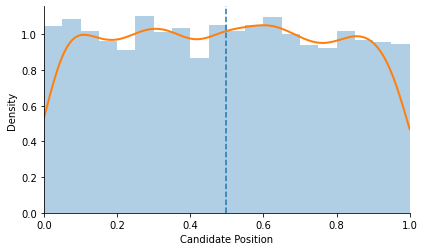

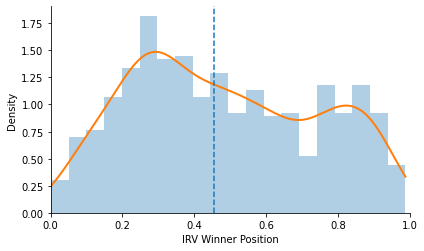

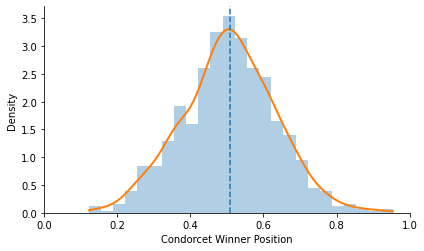

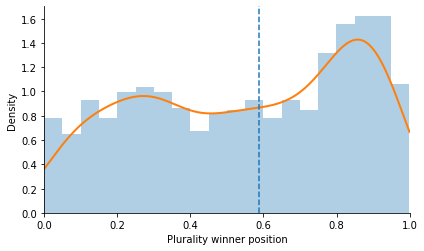

648
781
360


In [36]:
data = np.asarray(state_dist, float)
data = data[np.isfinite(data)]
rng = np.random.default_rng(0)
n_fit = min(200_000, data.size)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)          # for plotting only

# CANDIDATE DIST = UNIFORM on [xmin, xmax]
x_can = np.linspace(0.0, 1.0, 2048)  # evenly spaced!
y_can = np.ones_like(x_can)            # flat → uniform after normalization
candidate_dist = (x_can, y_can)


#candidate_dist = (x_grid, y_grid)

N_SIM = 1000
N_CANDIDATES = 5

irv_winners = []
condorcet_winners = []
plurality_winners = []
simulated_candidates = []
irv_condorcet_differences = 0
plurality_condorcet_differences = 0
irv_plurality_differences = 0

median_voter_condorcet = []
median_voter_irv = []
median_voter_plurality = [] 

condorcet_failure = 0
median_voter_theorem_failure = 0


c = 0
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, median_voter, median_voter_preference, condorcet, irv, plurality = \
        simulate(
            N_CANDIDATES,
            x_voter_plot=x_grid,
            y_voter_plot=y_grid,
            voter_dist=voter_kde,           # <-- KDE object so .resample works
            candidate_dist=candidate_dist,
            visualize=False
        )
    
    if(condorcet_winner == -1):
        condorcet_failure += 1
        continue

    if (condorcet_winner != median_voter_preference):
        median_voter_theorem_failure += 1
    
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))

    """print("median voter preference: ", median_voter_preference)
    print("condorcet winner: ", condorcet_winner)
    print("irv winner: ", irv_winner)
    print("plurality winner: ", plurality_winner)"""
    
    median_voter_condorcet.append(abs(condorcet_winner - median_voter_preference))
    median_voter_irv.append(abs(irv_winner - median_voter_preference))
    median_voter_plurality.append(abs(plurality_winner - median_voter_preference))

    if irv_winner != condorcet_winner:
        irv_condorcet_differences += 1
    if irv_winner != plurality_winner:
        irv_plurality_differences += 1
    if plurality_winner != condorcet_winner:
        plurality_condorcet_differences += 1

    simulated_candidates.extend(top_n_points)

    if (c % 100 == 0):
        print(c)
    c += 1
    
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)
simulated_candidates = np.asarray(simulated_candidates, float)

print("number of simulated elections: ", c)

#Top n points (candidate distribution)

bins = fd_bins(simulated_candidates)
kde_w = gaussian_kde(simulated_candidates, bw_method='scott')
xx = np.linspace(simulated_candidates.min(), simulated_candidates.max(), 1000)
yy = kde_w(xx)

med = float(np.median(simulated_candidates))
lo, hi = hdi(simulated_candidates, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(simulated_candidates, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Candidate Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


print(irv_condorcet_differences)
print(plurality_condorcet_differences)
print(irv_plurality_differences)

In [37]:
print(median_voter_theorem_failure)

240


0
100
200
300
400
500
600
700
800
900
number of simulated elections:  933


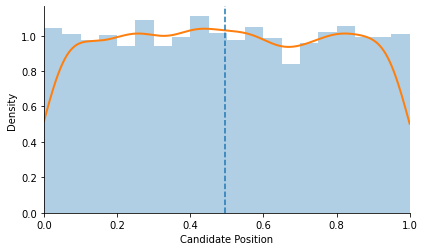

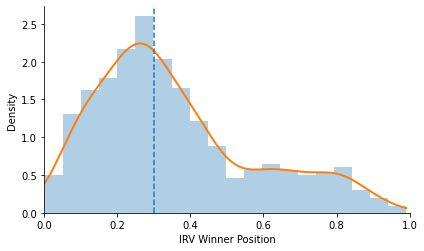

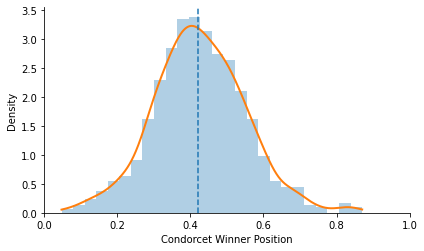

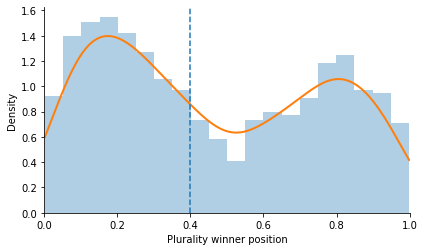

576
752
415


In [40]:
data = np.asarray(federal_dist, float)
data = data[np.isfinite(data)]
rng = np.random.default_rng(0)
n_fit = min(200_000, data.size)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)          # for plotting only

# CANDIDATE DIST = UNIFORM on [xmin, xmax]
x_can = np.linspace(0.0, 1.0, 2048)  # evenly spaced!
y_can = np.ones_like(x_can)            # flat → uniform after normalization
candidate_dist = (x_can, y_can)


#candidate_dist = (x_grid, y_grid)

N_SIM = 1000
N_CANDIDATES = 5

irv_winners = []
condorcet_winners = []
plurality_winners = []
simulated_candidates = []
irv_condorcet_differences = 0
plurality_condorcet_differences = 0
irv_plurality_differences = 0

median_voter_condorcet = []
median_voter_irv = []
median_voter_plurality = [] 

condorcet_failure = 0
median_voter_theorem_failure = 0


c = 0
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, median_voter, median_voter_preference, condorcet, irv, plurality = \
        simulate(
            N_CANDIDATES,
            x_voter_plot=x_grid,
            y_voter_plot=y_grid,
            voter_dist=voter_kde,           # <-- KDE object so .resample works
            candidate_dist=candidate_dist,
            visualize=False
        )
    
    if(condorcet_winner == -1):
        condorcet_failure += 1
        continue

    if (condorcet_winner != median_voter_preference):
        median_voter_theorem_failure += 1
    
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))

    """print("median voter preference: ", median_voter_preference)
    print("condorcet winner: ", condorcet_winner)
    print("irv winner: ", irv_winner)
    print("plurality winner: ", plurality_winner)"""
    
    median_voter_condorcet.append(abs(condorcet_winner - median_voter_preference))
    median_voter_irv.append(abs(irv_winner - median_voter_preference))
    median_voter_plurality.append(abs(plurality_winner - median_voter_preference))

    if irv_winner != condorcet_winner:
        irv_condorcet_differences += 1
    if irv_winner != plurality_winner:
        irv_plurality_differences += 1
    if plurality_winner != condorcet_winner:
        plurality_condorcet_differences += 1

    simulated_candidates.extend(top_n_points)

    if (c % 100 == 0):
        print(c)
    c += 1
    
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)
simulated_candidates = np.asarray(simulated_candidates, float)

print("number of simulated elections: ", c)

#Top n points (candidate distribution)

bins = fd_bins(simulated_candidates)
kde_w = gaussian_kde(simulated_candidates, bw_method='scott')
xx = np.linspace(simulated_candidates.min(), simulated_candidates.max(), 1000)
yy = kde_w(xx)

med = float(np.median(simulated_candidates))
lo, hi = hdi(simulated_candidates, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(simulated_candidates, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Candidate Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


print(irv_condorcet_differences)
print(plurality_condorcet_differences)
print(irv_plurality_differences)

In [41]:
print(median_voter_theorem_failure)

214


START HERE


In [7]:
df = pd.read_csv("election_table.csv")

directory = "np_data_new"
normalized_chunks_all, normalized_chunks_local = [], []
normalized_chunks_state, normalized_chunks_federal = [], []

normalized_chunks_partisan = []
normalized_chunks_non_partisan, normalized_chunks_primary = [], []

# ensure df has clean keys
df = df.copy()
df["filename"] = df["filename"].astype(str).str.strip()
df["level"]    = df["level"].astype(str).str.strip().str.upper()
level_map = df.set_index("filename")["level"].to_dict()

df2 = df.copy()
df2["filename"] = df2["filename"].astype(str).str.strip()
df2["partisan"]    = df2["partisan"].astype(str).str.strip().str.upper()
partisan_map = df2.set_index("filename")["partisan"].to_dict()

files = sorted(Path(directory).glob("*.npy"))
for fpath in files:
    dist = normalize_data(np.load(fpath, allow_pickle=False))
    if dist.size == 0:
        continue
    normalized_chunks_all.append(dist)

    fname_csv = fpath.with_suffix(".csv").name
    level = level_map.get(fname_csv)
    p = partisan_map.get(fname_csv)
    

    if level == "LOCAL":
        normalized_chunks_local.append(dist)
    elif level == "STATE":
        normalized_chunks_state.append(dist)
    elif level == "FEDERAL":
        normalized_chunks_federal.append(dist)
    
    if p == "YES":
        normalized_chunks_partisan.append(dist)
    elif p == "NO":
        normalized_chunks_non_partisan.append(dist)
    else:
        normalized_chunks_primary.append(dist)

all_dist     = np.concatenate(normalized_chunks_all)     if normalized_chunks_all     else np.array([], float)
local_dist   = np.concatenate(normalized_chunks_local)   if normalized_chunks_local   else np.array([], float)
state_dist   = np.concatenate(normalized_chunks_state)   if normalized_chunks_state   else np.array([], float)
federal_dist = np.concatenate(normalized_chunks_federal) if normalized_chunks_federal else np.array([], float)

partisan_dist   = np.concatenate(normalized_chunks_partisan)   if normalized_chunks_partisan   else np.array([], float)
non_partisan_dist   = np.concatenate(normalized_chunks_non_partisan)   if normalized_chunks_non_partisan   else np.array([], float)
primary_dist = np.concatenate(normalized_chunks_primary) if normalized_chunks_primary else np.array([], float)

print(f"Loaded {len(files)} files → combined length: {all_dist.size}")
print(f"Loaded {len(files)} primaryfiles → combined length: {primary_dist.size}")


Loaded 503 files → combined length: 17154841
Loaded 503 primaryfiles → combined length: 3831814


integrating the off immension voters' first place choice into simmulations

1. calculating the distribution of inconsistent voters' first place choice 


In [8]:
import os, pickle
import numpy as np
import pandas as pd

# --- CONFIG ---
directory = "dataverse_files_2025"                  # folder you iterate over
meta_table_path = "election_table.csv"              # must contain columns: filename, level

# load metadata and filter to STATE/FEDERAL
meta = pd.read_csv(meta_table_path, usecols=["filename", "level"])
meta["level"] = meta["level"].astype(str).str.strip().str.upper()
allowed = set(["LOCAL"])
keep_filenames = set(meta.loc[meta["level"].isin(allowed), "filename"].astype(str))

inconsistent_choices_local = []

for filename in os.listdir(directory):
    try:
        if filename not in keep_filenames:
            continue

        # 1) normalized_distances from null_elections/<filename>
        meta_path = os.path.join("null_elections", filename)
        df = pd.read_csv(meta_path, usecols=["candidate", "position"]).dropna(subset=["candidate", "position"])
        df["candidate"] = df["candidate"].astype(str).str.strip()

        # min–max normalize positions to [0,1]
        pmin, pmax = df["position"].min(), df["position"].max()
        den = pmax - pmin
        df["position_norm"] = (df["position"] - pmin) / den if den > 0 else 0.0

        # if duplicates exist, keep first row per candidate
        normalized_distances = (
            df.drop_duplicates("candidate", keep="first")
              .set_index("candidate")["position_norm"]
              .to_dict()
        )

        # 2) load ballots & candidates pickles
        stem = filename[:-4]
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_ballots.pkl"), "rb") as f:
            ballots = pickle.load(f)
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_candidates.pkl"), "rb") as f:
            candidates = pickle.load(f)

        # 3) collect first-choice positions for inconsistent ballots
        for b in ballots:
            if len(b) == 0:
                continue
            if not is_consistent(b, normalized_distances):
                # guard in case first-choice name not in dict
                first = b[0]
                if first in normalized_distances:
                    inconsistent_choices_local.append(float(normalized_distances[first]))

    except Exception as e:
        # optional: print or log the filename that failed
        # print(f"{filename} skipped due to: {e}")
        continue

# final array
inconsistent_choices_local = np.asarray(inconsistent_choices_local, dtype=float)
# print summary if you want
# print("Collected", inconsistent_choices.size, "inconsistent first-choice positions (STATE/FEDERAL).")




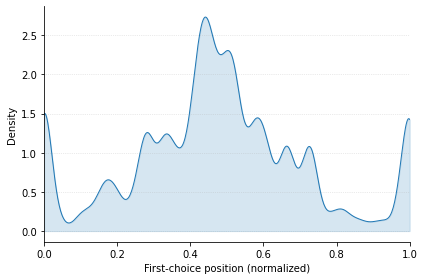

In [9]:
vals_local = np.asarray(inconsistent_choices_local, dtype=float)
vals_local = vals_local[np.isfinite(vals_local)]

if vals_local.size >= 2:
    # KDE on [0, 1]
    kde = gaussian_kde(vals_local)   # try 'silverman' or numbers like 0.8/1.2 to adjust smoothness
    x = np.linspace(0, 1, 512)
    y_local = kde(x)

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, y_local, lw=1.0, color="#1f77b4")
    ax.fill_between(x, 0, y_local, alpha=0.18, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_xlabel("First-choice position (normalized)")
    ax.set_ylabel("Density")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compute KDE (need at least 2 finite values).")

In [10]:

meta = pd.read_csv(meta_table_path, usecols=["filename", "level"])
meta["level"] = meta["level"].astype(str).str.strip().str.upper()
allowed = set(["STATE"])
keep_filenames = set(meta.loc[meta["level"].isin(allowed), "filename"].astype(str))

inconsistent_choices_state = []

for filename in os.listdir(directory):
    try:
        if filename not in keep_filenames:
            continue

        # 1) normalized_distances from null_elections/<filename>
        meta_path = os.path.join("null_elections", filename)
        df = pd.read_csv(meta_path, usecols=["candidate", "position"]).dropna(subset=["candidate", "position"])
        df["candidate"] = df["candidate"].astype(str).str.strip()

        # min–max normalize positions to [0,1]
        pmin, pmax = df["position"].min(), df["position"].max()
        den = pmax - pmin
        df["position_norm"] = (df["position"] - pmin) / den if den > 0 else 0.0

        # if duplicates exist, keep first row per candidate
        normalized_distances = (
            df.drop_duplicates("candidate", keep="first")
              .set_index("candidate")["position_norm"]
              .to_dict()
        )

        # 2) load ballots & candidates pickles
        stem = filename[:-4]
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_ballots.pkl"), "rb") as f:
            ballots = pickle.load(f)
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_candidates.pkl"), "rb") as f:
            candidates = pickle.load(f)

        # 3) collect first-choice positions for inconsistent ballots
        for b in ballots:
            if len(b) == 0:
                continue
            if not is_consistent(b, normalized_distances):
                # guard in case first-choice name not in dict
                first = b[0]
                if first in normalized_distances:
                    inconsistent_choices_state.append(float(normalized_distances[first]))

    except Exception as e:
        # optional: print or log the filename that failed
        # print(f"{filename} skipped due to: {e}")
        continue

# final array
inconsistent_choices_state = np.asarray(inconsistent_choices_state, dtype=float)
# print summary if you want
# print("Collected", inconsistent_choices.size, "inconsistent first-choice positions (STATE/FEDERAL).")




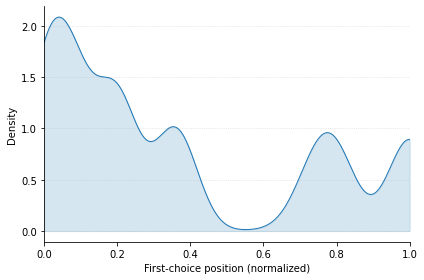

In [11]:
vals_state = np.asarray(inconsistent_choices_state, dtype=float)
vals_state = vals_state[np.isfinite(vals_state)]

if vals_state.size >= 2:
    # KDE on [0, 1]
    kde = gaussian_kde(vals_state)   # try 'silverman' or numbers like 0.8/1.2 to adjust smoothness
    x = np.linspace(0, 1, 512)
    y_state = kde(x)

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, y_state, lw=1.0, color="#1f77b4")
    ax.fill_between(x, 0, y_state, alpha=0.18, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_xlabel("First-choice position (normalized)")
    ax.set_ylabel("Density")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compute KDE (need at least 2 finite values).")

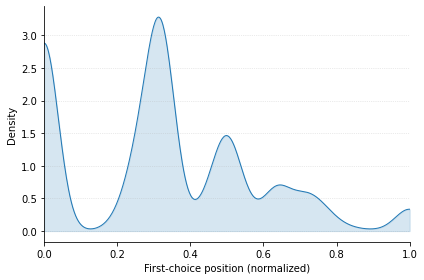

In [12]:

meta = pd.read_csv(meta_table_path, usecols=["filename", "level"])
meta["level"] = meta["level"].astype(str).str.strip().str.upper()
allowed = set(["FEDERAL"])
keep_filenames = set(meta.loc[meta["level"].isin(allowed), "filename"].astype(str))

inconsistent_choices_federal = []

for filename in os.listdir(directory):
    try:
        if filename not in keep_filenames:
            continue

        # 1) normalized_distances from null_elections/<filename>
        meta_path = os.path.join("null_elections", filename)
        df = pd.read_csv(meta_path, usecols=["candidate", "position"]).dropna(subset=["candidate", "position"])
        df["candidate"] = df["candidate"].astype(str).str.strip()

        # min–max normalize positions to [0,1]
        pmin, pmax = df["position"].min(), df["position"].max()
        den = pmax - pmin
        df["position_norm"] = (df["position"] - pmin) / den if den > 0 else 0.0

        # if duplicates exist, keep first row per candidate
        normalized_distances = (
            df.drop_duplicates("candidate", keep="first")
              .set_index("candidate")["position_norm"]
              .to_dict()
        )

        # 2) load ballots & candidates pickles
        stem = filename[:-4]
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_ballots.pkl"), "rb") as f:
            ballots = pickle.load(f)
        with open(os.path.join("saved_ballots_and_candidates", f"{stem}_candidates.pkl"), "rb") as f:
            candidates = pickle.load(f)

        # 3) collect first-choice positions for inconsistent ballots
        for b in ballots:
            if len(b) == 0:
                continue
            if not is_consistent(b, normalized_distances):
                # guard in case first-choice name not in dict
                first = b[0]
                if first in normalized_distances:
                    inconsistent_choices_federal.append(float(normalized_distances[first]))

    except Exception as e:
        # optional: print or log the filename that failed
        # print(f"{filename} skipped due to: {e}")
        continue

# final array
inconsistent_choices_federal = np.asarray(inconsistent_choices_federal, dtype=float)
# print summary if you want
# print("Collected", inconsistent_choices.size, "inconsistent first-choice positions (STATE/FEDERAL).")


vals_federal = np.asarray(inconsistent_choices_federal, dtype=float)
vals_federal = vals_federal[np.isfinite(vals_federal)]

if vals_federal.size >= 2:
    # KDE on [0, 1]
    kde = gaussian_kde(vals_federal)   # try 'silverman' or numbers like 0.8/1.2 to adjust smoothness
    x = np.linspace(0, 1, 512)
    y_federal = kde(x)

    # plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, y_federal, lw=1.0, color="#1f77b4")
    ax.fill_between(x, 0, y_federal, alpha=0.18, color="#1f77b4")

    ax.set_xlim(0, 1)
    ax.set_xlabel("First-choice position (normalized)")
    ax.set_ylabel("Density")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7, alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to compute KDE (need at least 2 finite values).")

2. Simulations


number of simulated elections:  928


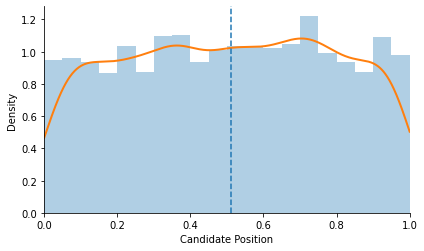

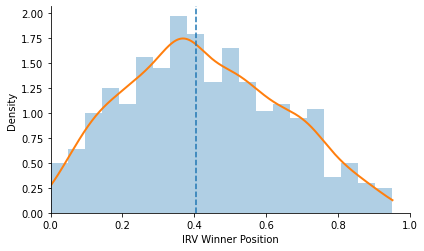

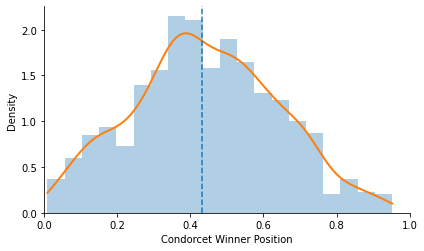

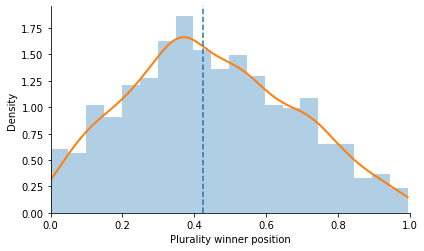

IRV vs Condorcet:  117
Plurality vs Condorcet:  163
IRV vs Plurality:  84
MVT Failure:  320


In [16]:
# N = 3, STATE
data = np.asarray(state_dist, float)
data = data[np.isfinite(data)]
rng = np.random.default_rng(0)
n_fit = min(200_000, data.size)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)          # for plotting only

# CANDIDATE DIST = UNIFORM on [xmin, xmax]
x_can = np.linspace(0.0, 1.0, 2048)  # evenly spaced!
y_can = np.ones_like(x_can)            # flat → uniform after normalization
candidate_dist = (x_can, y_can)


N_SIM = 1000
N_CANDIDATES = 3

irv_winners = []
condorcet_winners = []
plurality_winners = []
simulated_candidates = []
irv_condorcet_differences = 0
plurality_condorcet_differences = 0
irv_plurality_differences = 0

median_voter_condorcet = []
median_voter_irv = []
median_voter_plurality = [] 
gamma_dist_state_3 = []

condorcet_failure = 0
median_voter_theorem_failure = 0
level = "STATE"

c = 0
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, median_voter, median_voter_preference, condorcet, irv, plurality = \
    top_n_gamma(
        N_CANDIDATES,
        x_voter_plot=x_grid,
        y_voter_plot=y_grid,
        voter_dist=voter_kde,           # <-- KDE object so .resample works
        candidate_dist=candidate_dist,
        nl_dist = vals_state,
        level = level,
        visualize=False
    )

    gamma_dist_state_3.append(gamma)
    
    if(condorcet_winner == -1):
        condorcet_failure += 1
        continue

    if (condorcet_winner != median_voter_preference):
        median_voter_theorem_failure += 1
    
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))

    """print("median voter preference: ", median_voter_preference)
    print("condorcet winner: ", condorcet_winner)
    print("irv winner: ", irv_winner)
    print("plurality winner: ", plurality_winner)"""
    
    median_voter_condorcet.append(abs(condorcet_winner - median_voter_preference))
    median_voter_irv.append(abs(irv_winner - median_voter_preference))
    median_voter_plurality.append(abs(plurality_winner - median_voter_preference))

    if irv_winner != condorcet_winner:
        irv_condorcet_differences += 1
    if irv_winner != plurality_winner:
        irv_plurality_differences += 1
    if plurality_winner != condorcet_winner:
        plurality_condorcet_differences += 1

    simulated_candidates.extend(top_n_points)

    
    c += 1
    
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)
simulated_candidates = np.asarray(simulated_candidates, float)
gamma_dist_state_3 = np.asarray(gamma_dist_state_3, float)

print("number of simulated elections: ", c)

#Top n points (candidate distribution)

bins = fd_bins(simulated_candidates)
kde_w = gaussian_kde(simulated_candidates, bw_method='scott')
xx = np.linspace(simulated_candidates.min(), simulated_candidates.max(), 1000)
yy = kde_w(xx)

med = float(np.median(simulated_candidates))
lo, hi = hdi(simulated_candidates, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(simulated_candidates, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Candidate Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


print("IRV vs Condorcet: ", irv_condorcet_differences)
print("Plurality vs Condorcet: ", plurality_condorcet_differences)
print("IRV vs Plurality: ", irv_plurality_differences)
print("MVT Failure: ", median_voter_theorem_failure)

Ploting some other metrics

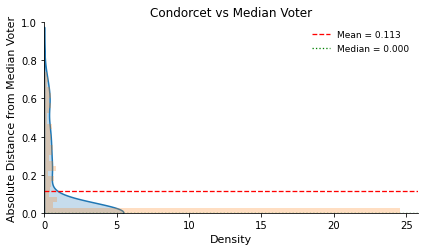

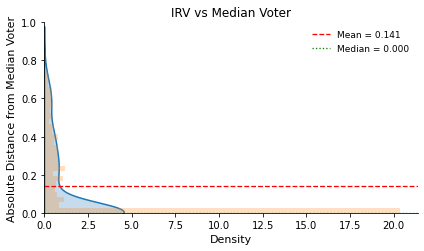

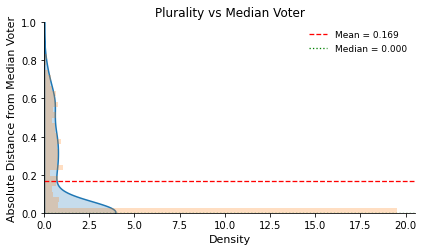

In [19]:
# --- Replacement block: Median voter distance plots with y-axis = distance in [0,1] ---

import seaborn as sns

def clean_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    return ax

mv_differences = {
    "Condorcet vs Median Voter": median_voter_condorcet,
    "IRV vs Median Voter": median_voter_irv,
    "Plurality vs Median Voter": median_voter_plurality
}

for label, data in mv_differences.items():
    plt.figure(figsize=(6, 3.6))

    # Density (x) vs Distance (y)
    # KDE with y as the variable places distance on the vertical axis
    sns.kdeplot(y=data, fill=True, alpha=0.25, linewidth=1.5)
    # Light histogram, horizontal so distance remains on y
    sns.histplot(y=data, bins=30, stat="density", alpha=0.25, edgecolor='none')

    # Mean/median lines across x (density) at the appropriate y (distance)
    mean_y = float(np.mean(data))
    med_y  = float(np.median(data))
    plt.axhline(mean_y, color='red', linestyle='--', linewidth=1.3, label=f"Mean = {mean_y:.3f}")
    plt.axhline(med_y,  color='green', linestyle=':', linewidth=1.3, label=f"Median = {med_y:.3f}")

    # Labels and bounds
    plt.ylabel("Absolute Distance from Median Voter", fontsize=11)
    plt.xlabel("Density", fontsize=11)
    plt.ylim(0, 1)  # distances live in [0,1]
    plt.title(label, fontsize=12)
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    clean_axis(plt.gca())
    plt.show()


number of simulated elections:  989


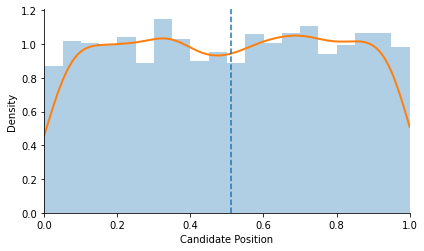

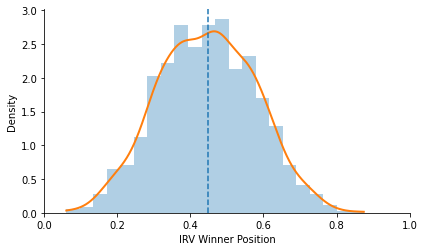

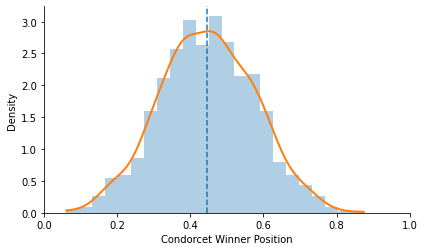

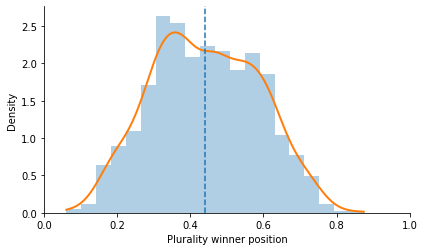

IRV vs Condorcet:  57
Plurality vs Condorcet:  194
IRV vs Plurality:  160
MVT Failure:  102


In [24]:
# N = 4, LOCAL
data = np.asarray(local_dist, float)
data = data[np.isfinite(data)]
rng = np.random.default_rng(0)
n_fit = min(200_000, data.size)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)          # for plotting only

# CANDIDATE DIST = UNIFORM on [xmin, xmax]
x_can = np.linspace(0.0, 1.0, 2048)  # evenly spaced!
y_can = np.ones_like(x_can)            # flat → uniform after normalization
candidate_dist = (x_can, y_can)


N_SIM = 1000
N_CANDIDATES = 4

irv_winners = []
condorcet_winners = []
plurality_winners = []
simulated_candidates = []
irv_condorcet_differences = 0
plurality_condorcet_differences = 0
irv_plurality_differences = 0

median_voter_condorcet = []
median_voter_irv = []
median_voter_plurality = [] 

gamma_dist_local_3 = []

condorcet_failure = 0
median_voter_theorem_failure = 0
level = "LOCAL"


c = 0
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, median_voter, median_voter_preference, condorcet, irv, plurality = \
    top_n_gamma(
        N_CANDIDATES,
        x_voter_plot=x_grid,
        y_voter_plot=y_grid,
        voter_dist=voter_kde,           # <-- KDE object so .resample works
        candidate_dist=candidate_dist,
        nl_dist = vals_local,
        level = level,
        visualize=False
    )
    
    gamma_dist_local_3.append(gamma)

    if(condorcet_winner == -1):
        condorcet_failure += 1
        continue

    if (condorcet_winner != median_voter_preference):
        median_voter_theorem_failure += 1
    
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))

    """print("median voter preference: ", median_voter_preference)
    print("condorcet winner: ", condorcet_winner)
    print("irv winner: ", irv_winner)
    print("plurality winner: ", plurality_winner)"""
    
    median_voter_condorcet.append(abs(condorcet_winner - median_voter_preference))
    median_voter_irv.append(abs(irv_winner - median_voter_preference))
    median_voter_plurality.append(abs(plurality_winner - median_voter_preference))

    if irv_winner != condorcet_winner:
        irv_condorcet_differences += 1
    if irv_winner != plurality_winner:
        irv_plurality_differences += 1
    if plurality_winner != condorcet_winner:
        plurality_condorcet_differences += 1

    simulated_candidates.extend(top_n_points)

   
    c += 1
    
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)
simulated_candidates = np.asarray(simulated_candidates, float)
gamma_dist_local_3 = np.asarray(gamma_dist_local_3, float)


print("number of simulated elections: ", c)

#Top n points (candidate distribution)

bins = fd_bins(simulated_candidates)
kde_w = gaussian_kde(simulated_candidates, bw_method='scott')
xx = np.linspace(simulated_candidates.min(), simulated_candidates.max(), 1000)
yy = kde_w(xx)

med = float(np.median(simulated_candidates))
lo, hi = hdi(simulated_candidates, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(simulated_candidates, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Candidate Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


print("IRV vs Condorcet: ", irv_condorcet_differences)
print("Plurality vs Condorcet: ", plurality_condorcet_differences)
print("IRV vs Plurality: ", irv_plurality_differences)
print("MVT Failure: ", median_voter_theorem_failure)

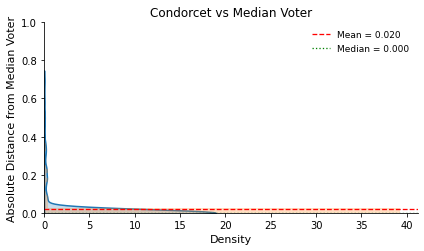

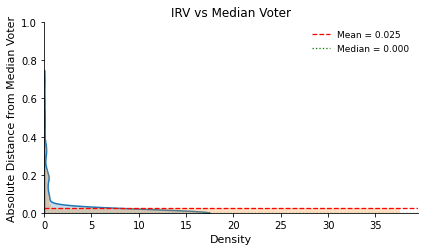

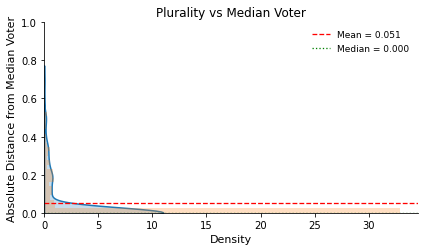

In [25]:
# --- Replacement block: Median voter distance plots with y-axis = distance in [0,1] ---

import seaborn as sns

def clean_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    return ax

mv_differences = {
    "Condorcet vs Median Voter": median_voter_condorcet,
    "IRV vs Median Voter": median_voter_irv,
    "Plurality vs Median Voter": median_voter_plurality
}

for label, data in mv_differences.items():
    plt.figure(figsize=(6, 3.6))

    # Density (x) vs Distance (y)
    # KDE with y as the variable places distance on the vertical axis
    sns.kdeplot(y=data, fill=True, alpha=0.25, linewidth=1.5)
    # Light histogram, horizontal so distance remains on y
    sns.histplot(y=data, bins=30, stat="density", alpha=0.25, edgecolor='none')

    # Mean/median lines across x (density) at the appropriate y (distance)
    mean_y = float(np.mean(data))
    med_y  = float(np.median(data))
    plt.axhline(mean_y, color='red', linestyle='--', linewidth=1.3, label=f"Mean = {mean_y:.3f}")
    plt.axhline(med_y,  color='green', linestyle=':', linewidth=1.3, label=f"Median = {med_y:.3f}")

    # Labels and bounds
    plt.ylabel("Absolute Distance from Median Voter", fontsize=11)
    plt.xlabel("Density", fontsize=11)
    plt.ylim(0, 1)  # distances live in [0,1]
    plt.title(label, fontsize=12)
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    clean_axis(plt.gca())
    plt.show()


0
100
200
300
400
500
600
700
800
900
number of simulated elections:  937


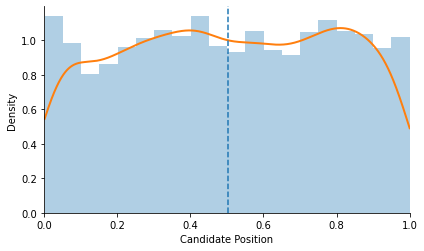

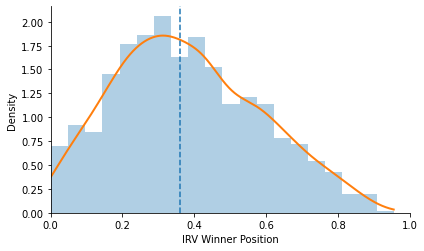

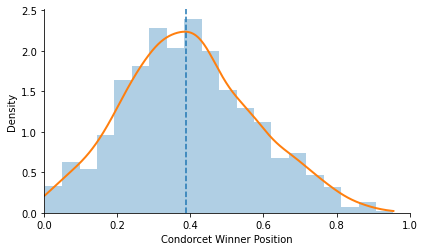

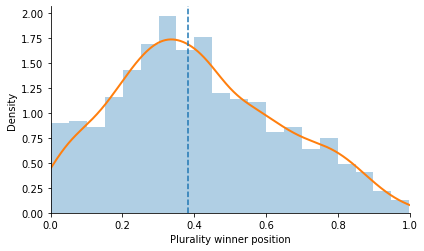

IRV vs Condorcet:  136
Plurality vs Condorcet:  205
IRV vs Plurality:  101
MVT Failure:  231


In [22]:
# n = 3, FEDERAL
data = np.asarray(federal_dist, float)
data = data[np.isfinite(data)]
rng = np.random.default_rng(0)
n_fit = min(200_000, data.size)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)          # for plotting only

# CANDIDATE DIST = UNIFORM on [xmin, xmax]
x_can = np.linspace(0.0, 1.0, 2048)  # evenly spaced!
y_can = np.ones_like(x_can)            # flat → uniform after normalization
candidate_dist = (x_can, y_can)


N_SIM = 1000
N_CANDIDATES = 3

irv_winners = []
condorcet_winners = []
plurality_winners = []
simulated_candidates = []
irv_condorcet_differences = 0
plurality_condorcet_differences = 0
irv_plurality_differences = 0

median_voter_condorcet = []
median_voter_irv = []
median_voter_plurality = [] 

gamma_dist_federal_3 = []

condorcet_failure = 0
median_voter_theorem_failure = 0

level = "FEDERAL"

c = 0
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, median_voter, median_voter_preference, condorcet, irv, plurality = \
    top_n_gamma(
        N_CANDIDATES,
        x_voter_plot=x_grid,
        y_voter_plot=y_grid,
        voter_dist=voter_kde,           # <-- KDE object so .resample works
        candidate_dist=candidate_dist,
        nl_dist = vals_federal,
        level = level,
        visualize=False
    )
    
    gamma_dist_federal_3.append(gamma)

    if(condorcet_winner == -1):
        condorcet_failure += 1
        continue

    if (condorcet_winner != median_voter_preference):
        median_voter_theorem_failure += 1
    
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))

    """print("median voter preference: ", median_voter_preference)
    print("condorcet winner: ", condorcet_winner)
    print("irv winner: ", irv_winner)
    print("plurality winner: ", plurality_winner)"""
    
    median_voter_condorcet.append(abs(condorcet_winner - median_voter_preference))
    median_voter_irv.append(abs(irv_winner - median_voter_preference))
    median_voter_plurality.append(abs(plurality_winner - median_voter_preference))

    if irv_winner != condorcet_winner:
        irv_condorcet_differences += 1
    if irv_winner != plurality_winner:
        irv_plurality_differences += 1
    if plurality_winner != condorcet_winner:
        plurality_condorcet_differences += 1

    simulated_candidates.extend(top_n_points)

    if (c % 100 == 0):
        print(c)
    c += 1
    
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)
simulated_candidates = np.asarray(simulated_candidates, float)
gamma_dist_federal_3 = np.asarray(gamma_dist_federal_3, float)

print("number of simulated elections: ", c)

#Top n points (candidate distribution)

bins = fd_bins(simulated_candidates)
kde_w = gaussian_kde(simulated_candidates, bw_method='scott')
xx = np.linspace(simulated_candidates.min(), simulated_candidates.max(), 1000)
yy = kde_w(xx)

med = float(np.median(simulated_candidates))
lo, hi = hdi(simulated_candidates, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(simulated_candidates, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Candidate Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()


print("IRV vs Condorcet: ", irv_condorcet_differences)
print("Plurality vs Condorcet: ", plurality_condorcet_differences)
print("IRV vs Plurality: ", irv_plurality_differences)
print("MVT Failure: ", median_voter_theorem_failure)

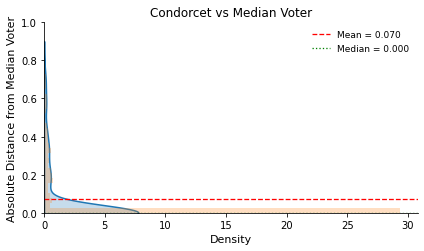

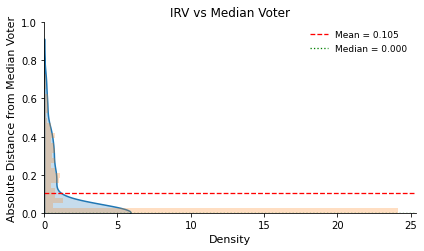

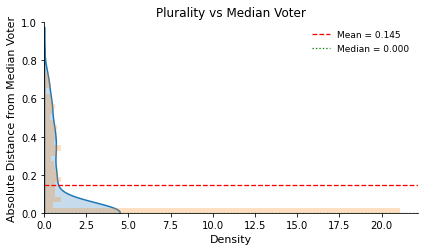

In [23]:
# --- Replacement block: Median voter distance plots with y-axis = distance in [0,1] ---

import seaborn as sns

def clean_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    return ax

mv_differences = {
    "Condorcet vs Median Voter": median_voter_condorcet,
    "IRV vs Median Voter": median_voter_irv,
    "Plurality vs Median Voter": median_voter_plurality
}

for label, data in mv_differences.items():
    plt.figure(figsize=(6, 3.6))

    # Density (x) vs Distance (y)
    # KDE with y as the variable places distance on the vertical axis
    sns.kdeplot(y=data, fill=True, alpha=0.25, linewidth=1.5)
    # Light histogram, horizontal so distance remains on y
    sns.histplot(y=data, bins=30, stat="density", alpha=0.25, edgecolor='none')

    # Mean/median lines across x (density) at the appropriate y (distance)
    mean_y = float(np.mean(data))
    med_y  = float(np.median(data))
    plt.axhline(mean_y, color='red', linestyle='--', linewidth=1.3, label=f"Mean = {mean_y:.3f}")
    plt.axhline(med_y,  color='green', linestyle=':', linewidth=1.3, label=f"Median = {med_y:.3f}")

    # Labels and bounds
    plt.ylabel("Absolute Distance from Median Voter", fontsize=11)
    plt.xlabel("Density", fontsize=11)
    plt.ylim(0, 1)  # distances live in [0,1]
    plt.title(label, fontsize=12)
    plt.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    clean_axis(plt.gca())
    plt.show()


In [11]:
c = 0
for e in median_voter_plurality:
    if e != 0:
        c += 1
print(c)
print(len(median_voter_plurality))
print(c/len(median_voter_plurality))

776
1000
0.776


State Distribution

In [1]:
# ---- build a KDE + grid for voters (use KDE object later) ----
data = np.asarray(state_dist, float)
data = data[np.isfinite(data)]
n_fit = min(200_000, data.size)
rng = np.random.default_rng(0)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)
candidate_dist = (x_grid, y_grid)

NameError: name 'np' is not defined

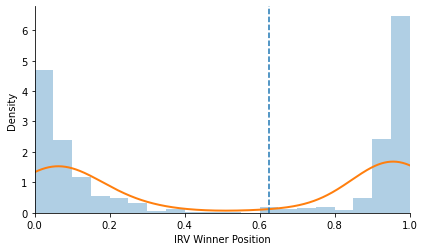

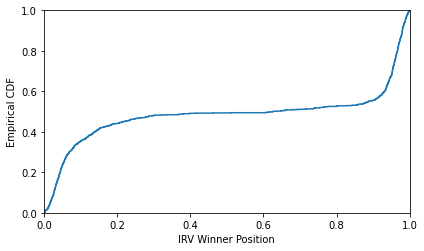

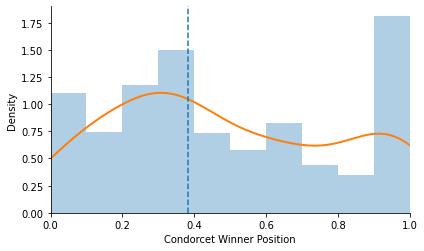

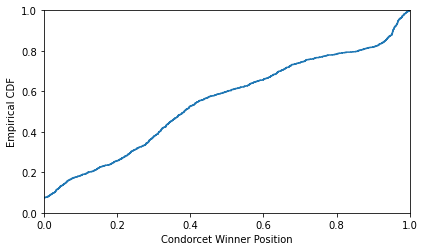

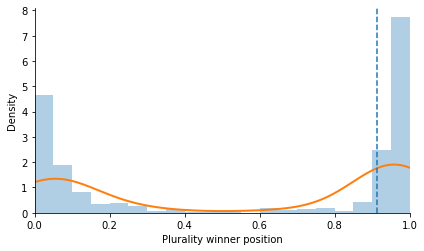

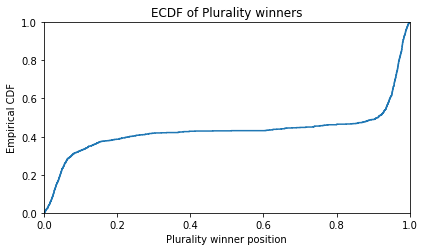

In [12]:
# ---- build a KDE + grid for voters (use KDE object later) ----
data = np.asarray(state_dist, float)
data = data[np.isfinite(data)]
n_fit = min(200_000, data.size)
rng = np.random.default_rng(0)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)
candidate_dist = (x_grid, y_grid)

N_SIM = 1000
N_CANDIDATES = 4

irv_winners = []
condorcet_winners = []
plurality_winners = []
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, condorcet, irv, plurality = \
        top_n_gamma(
            N_CANDIDATES,
            x_voter_plot=x_grid,
            y_voter_plot=y_grid,
            voter_dist=voter_kde,           # <-- KDE object so .resample works
            candidate_dist=candidate_dist,
            visualize=False
        )
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)




# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(irv_winners)
y_ecdf = np.arange(1, irv_winners.size + 1) / irv_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("IRV Winner Position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
#plt.title("ECDF of IRV winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(condorcet_winners)
y_ecdf = np.arange(1, condorcet_winners.size + 1) / condorcet_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("Condorcet Winner Position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
#plt.title("ECDF of IRV winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()



# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(plurality_winners)
y_ecdf = np.arange(1, plurality_winners.size + 1) / plurality_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("Plurality winner position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("ECDF of Plurality winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()

Federal Distribution

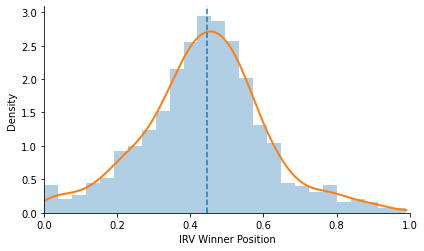

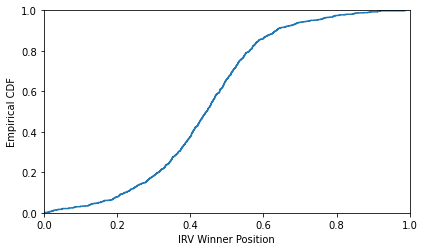

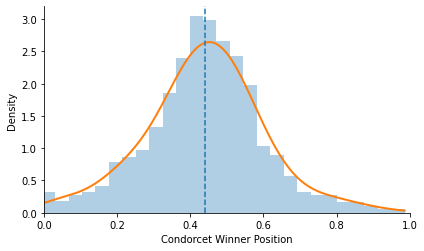

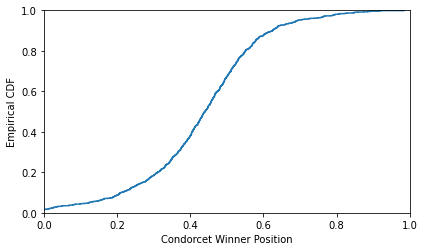

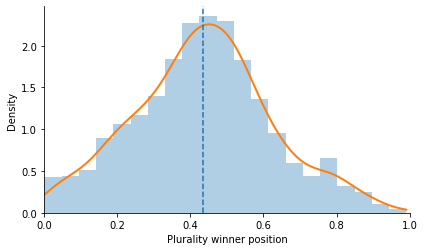

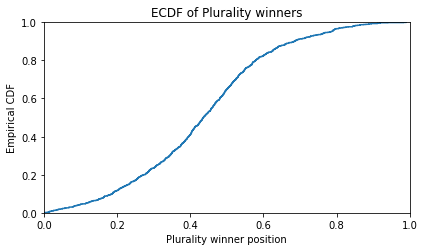

In [6]:
# ---- build a KDE + grid for voters (use KDE object later) ----
data = np.asarray(all_dist, float)
data = data[np.isfinite(data)]
n_fit = min(200_000, data.size)
rng = np.random.default_rng(0)
fit = data if data.size <= n_fit else data[rng.choice(data.size, n_fit, replace=False)]
voter_kde = gaussian_kde(fit, bw_method='scott')

xmin, xmax = float(data.min()), float(data.max())
x_grid = np.linspace(xmin, xmax, 2048)
y_grid = voter_kde(x_grid)
candidate_dist = (x_grid, y_grid)

N_SIM = 1000
N_CANDIDATES = 3

irv_winners = []
condorcet_winners = []
plurality_winners = []
for i in range(N_SIM):
    irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, condorcet, irv, plurality = \
        top_n_gamma(
            N_CANDIDATES,
            x_voter_plot=x_grid,
            y_voter_plot=y_grid,
            voter_dist=voter_kde,           # <-- KDE object so .resample works
            candidate_dist=candidate_dist,
            visualize=False
        )
    irv_winners.append(float(irv_winner))
    condorcet_winners.append(float(condorcet_winner))
    plurality_winners.append(float(plurality_winner))
irv_winners = np.asarray(irv_winners, float)
condorcet_winners = np.asarray(condorcet_winners, float)
plurality_winners = np.asarray(plurality_winners, float)




# IRV Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(irv_winners)
y_ecdf = np.arange(1, irv_winners.size + 1) / irv_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("IRV Winner Position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
#plt.title("ECDF of IRV winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()



# Condorcet Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(condorcet_winners)
y_ecdf = np.arange(1, condorcet_winners.size + 1) / condorcet_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("Condorcet Winner Position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
#plt.title("ECDF of IRV winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()



# Plurality Winners
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(plurality_winners)
y_ecdf = np.arange(1, plurality_winners.size + 1) / plurality_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("Plurality winner position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("ECDF of Plurality winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()

IRV Winners Distribution

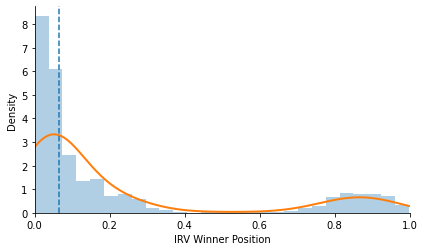

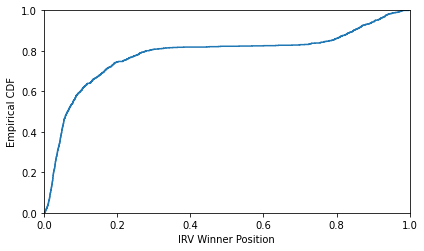

In [12]:
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(irv_winners)
kde_w = gaussian_kde(irv_winners, bw_method='scott')
xx = np.linspace(irv_winners.min(), irv_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(irv_winners))
lo, hi = hdi(irv_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(irv_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("IRV Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(irv_winners)
y_ecdf = np.arange(1, irv_winners.size + 1) / irv_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("IRV Winner Position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
#plt.title("ECDF of IRV winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()

Condorcet Winner Distribution

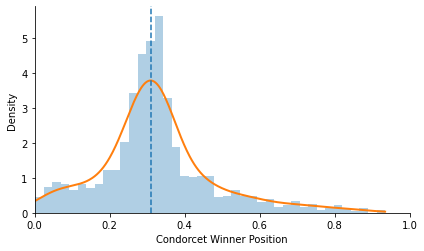

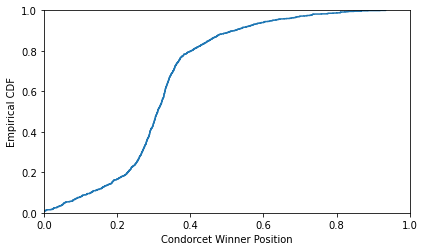

In [13]:
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(condorcet_winners)
kde_w = gaussian_kde(condorcet_winners, bw_method='scott')
xx = np.linspace(condorcet_winners.min(), condorcet_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(condorcet_winners))
lo, hi = hdi(condorcet_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(condorcet_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Condorcet Winner Position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(condorcet_winners)
y_ecdf = np.arange(1, condorcet_winners.size + 1) / condorcet_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("Condorcet Winner Position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
#plt.title("ECDF of IRV winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()

Plurality Winners Distribution

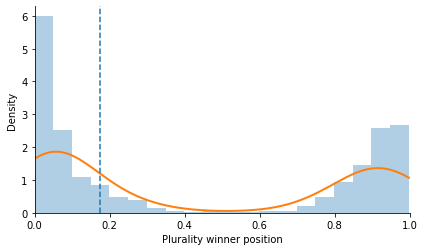

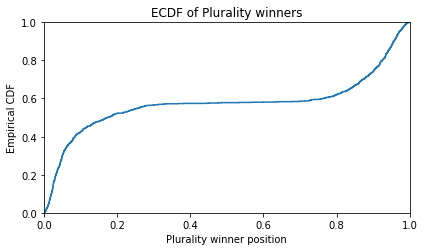

In [14]:
# ---------- main figure: histogram + KDE + median + 95% HDI ----------
bins = fd_bins(plurality_winners)
kde_w = gaussian_kde(plurality_winners, bw_method='scott')
xx = np.linspace(plurality_winners.min(), plurality_winners.max(), 1000)
yy = kde_w(xx)

med = float(np.median(plurality_winners))
lo, hi = hdi(plurality_winners, alpha=0.05)

plt.figure(figsize=(6.0, 3.6))
plt.hist(plurality_winners, bins=bins, density=True, alpha=0.35, edgecolor='none')
plt.plot(xx, yy, linewidth=2)
plt.axvline(med, linestyle='--', linewidth=1.5)
#plt.axvspan(lo, hi, alpha=0.15)

plt.xlabel("Plurality winner position")
plt.ylabel("Density")
plt.xlim(0, 1)  # positions are normalized in your pipeline
#plt.title(f"Distribution of IRV winners over {N_SIM} simulations")
plt.tight_layout()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(top=False, right=False)
# Save at publication quality
#plt.savefig("irv_winner_distribution.pdf")
#plt.savefig("irv_winner_distribution.png", dpi=300)
plt.show()

# ---------- optional: ECDF (nice for appendix) ----------
x_sorted = np.sort(plurality_winners)
y_ecdf = np.arange(1, plurality_winners.size + 1) / plurality_winners.size
plt.figure(figsize=(6.0, 3.6))
plt.step(x_sorted, y_ecdf, where='post')
plt.xlabel("Plurality winner position")
plt.ylabel("Empirical CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("ECDF of Plurality winners")
plt.tight_layout()
plt.savefig("irv_winner_ecdf.pdf")
plt.savefig("irv_winner_ecdf.png", dpi=300)
plt.show()

In [27]:
print(irv_winner)
print(plurality_winner)
print(condorcet_winner)

0.43234000977039566
0.8959452857840742
0.43234000977039566


Albany_11082022_FAKECityCouncil.csv   list index out of range
[[-2.10873215e-02  9.35119363e-01  5.38477850e-01  5.78490465e-01
   9.99593057e-01  8.97567820e-01  3.82756276e-01  5.23416172e-01
   4.09676187e-01  9.98839151e-01  8.46288698e-01  9.34562901e-01
   2.66862827e-01  1.01957434e+00  1.02321142e+00  1.05107207e+00
  -4.78469676e-02  6.60465808e-01  6.95906970e-02  1.99049160e-01
   1.01758119e+00  6.22580397e-01  9.78100157e-01 -3.54529617e-02
   9.39612449e-01 -4.36309661e-02 -3.87556492e-02  2.31745553e-01
   1.01739813e+00 -3.93149515e-02  2.43008787e-02  9.99229688e-03
   9.55983759e-01  7.77380432e-01  9.63363511e-02  5.29948989e-01
   7.55110739e-01  7.21763554e-01  1.86958293e-01  9.56035676e-02
   7.60521820e-01  6.90908746e-02 -2.44909625e-02  2.71260394e-01
   7.62839741e-01  1.25951575e-01  1.00193082e+00 -2.45005103e-04
   1.69895863e-01  3.31946697e-02  7.45866347e-02  1.01576890e+00
  -1.56963437e-02  2.37342042e-01  5.72858889e-02  5.84370827e-01
   6.53923433e

ValueError: x and y must be the same size

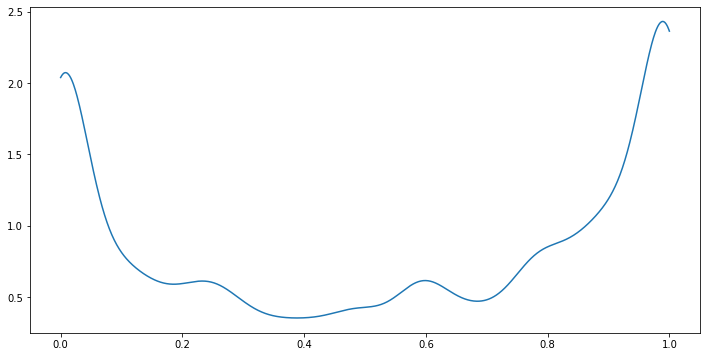

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


directory = "np_data_new"
df = pd.read_csv("median_voter_analysis.csv")
partisan_data = {'YES': [], 'NO': []}

for file in os.listdir(directory):
    try:
        filename = file[0:-4] + ".csv"
        if df.loc[df["filename"] == filename, "#candidates"].tolist()[0] > 2:
            data = np.load(os.path.join(directory, file))

            # Normalize the data
            data = normalize_data(data)

            partisan = df.loc[df["filename"] == filename, "partisan"].tolist()[0]
            if partisan in partisan_data:
                partisan_data[partisan].extend(data)  # Accumulate the normalized data

    except Exception as e:
        print(filename, " ", e)

# Calculate and plot KDEs for the accumulated data
plt.figure(figsize=(12, 6))
sampled_points = {}
for key, data in partisan_data.items():
    if data:  # Check if there is data for the group
        kde = gaussian_kde(data, bw_method=0.1)
        x = np.linspace(np.min(data), np.max(data), 1000)
        kde_values = kde(x)
        
        # Plot the KDE
        plt.plot(x, kde_values, label=f'KDE {key}')
        
        # Sample 1000 points from the KDE
        sampled_points[key] = kde.resample(size=1000)
        print(sampled_points[key])
        # Plot the sampled points
        plt.scatter(sampled_points[key], np.zeros_like(sampled_points) + np.max(kde_values) * 0.1, label=f'Sampled Points {key}', alpha=0.5)

plt.xlabel('Normalized Data')
plt.ylabel('Density')
plt.legend()
plt.title('KDE and Sampled Points')
plt.show()


In [643]:
def generate_permutations(items, k):
    all_permutations = []
    
    for length in range(1, k + 1):
        perms = permutations(items, length)
        all_permutations.extend(perms)
    
    return all_permutations

In [ ]:
# This function is generating totaly random ballots instead of the inconsistent ones (not keeping the first place choices)

def generate_random_inconsistent_ballots(ballots, candidates, filename):
    filename = filename + ".csv"
    election = pd.read_csv("election_table.csv")
    choices = min(len(candidates), round(election.loc[election['filename']==filename, 'choices'].values[0]))
    if choices == 1:
        choices = len(candidates)

    #print(choices)
    directory = "null_elections"
    csv = os.path.join(directory, filename) 
    df = pd.read_csv(csv)

    perms = generate_permutations(candidates, choices)

    normalized_distances = pd.Series(df['position'].values, index=df['candidate']).to_dict()
    #print(normalized_distances)
    consistent_ballots, gamma = get_permissive_gamma(ballots, normalized_distances)

    perms = [perm for perm in perms if (perm not in consistent_ballots) and is_consistent(perm, normalized_distances)==False]    
    
   
    all_voters = 0
    for b in ballots:
        if len(b) > 0:
            all_voters += ballots[b]
    consistent_voters = sum(consistent_ballots.values())
    inconsistent_voters = all_voters - consistent_voters
    inconsistent_ballots_list = random.choices(perms, k=inconsistent_voters)
    inconsistent_ballots = {}

    for ballot in inconsistent_ballots_list:
        if ballot not in inconsistent_ballots:
            inconsistent_ballots[ballot] = 0
        inconsistent_ballots[ballot] += 1

    return inconsistent_ballots, consistent_ballots
    

In [ ]:
def generate_ballots(data, candidates_positions):
    

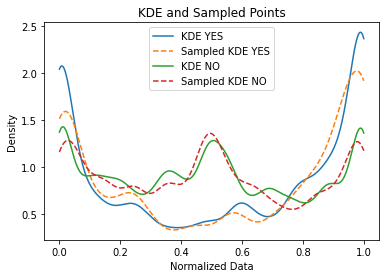

In [28]:
for key, data in partisan_data.items():
    if data:  # Check if there is data for the group
        kde = gaussian_kde(data, bw_method=0.1)
        x = np.linspace(np.min(data), np.max(data), 1000)
        kde_values = kde(x)
        
        # Plot the KDE
        plt.plot(x, kde_values, label=f'KDE {key}')
        
        # Sample 1000 points from the KDE
        sampled_points = kde.resample(size=1000)
        kde_sampled = gaussian_kde(sampled_points.flatten(), bw_method=0.1)
        kde_sampled_values = kde_sampled(x)
        
        # Plot the KDE of sampled points
        plt.plot(x, kde_sampled_values, '--', label=f'Sampled KDE {key}')
plt.xlabel('Normalized Data')
plt.ylabel('Density')
plt.legend()
plt.title('KDE and Sampled Points')
plt.show()


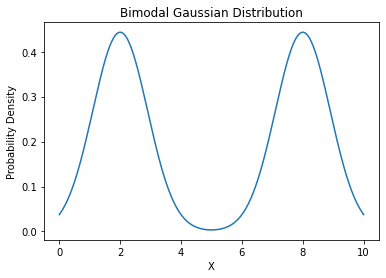

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the parameters for the two Gaussians
mu1, sigma1 = 2, 0.9
mu2, sigma2 = 8, 0.9

# Create a range of x values
x = np.linspace(0, 10, 1000)

# Create the bimodal distribution
y1 = norm.pdf(x, mu1, sigma1)
y2 = norm.pdf(x, mu2, sigma2)
y = y1 + y2

# Plot the bimodal distribution
plt.plot(x, y)
plt.title('Bimodal Gaussian Distribution')
plt.xlabel('X')
plt.ylabel('Probability Density')
plt.show()


In [42]:
# Split the x-axis into two halves
midpoint = len(x) // 2
x_left = x[:midpoint]
x_right = x[midpoint:]
y_left = y[:midpoint]
y_right = y[midpoint:]
# Generate 5 random points for each half
np.random.seed(0)  # For reproducibility
random_points_left = np.random.choice(x_left, 5, replace=False)
random_points_right = np.random.choice(x_right, 5, replace=False)


In [43]:
from scipy.integrate import quad

# Function to compute the area under the curve
def area_under_curve(x_val, x, y):
    idx = np.searchsorted(x, x_val)
    integral, _ = quad(lambda t: np.interp(t, x, y), x[0], x_val)
    return integral

# Calculate the area for each random point
areas_left = [area_under_curve(p, x, y) for p in random_points_left]
areas_right = [area_under_curve(p, x, y) for p in random_points_right]

# Combine points and areas
points = np.concatenate((random_points_left, random_points_right))
areas = np.concatenate((areas_left, areas_right))


C:\Users\mahsh\AppData\Local\Temp\ipykernel_13320\1560956951.py:6: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(lambda t: np.interp(t, x, y), x[0], x_val)


In [44]:
# Define the number of top points to select
n = 3  # For example

# Get indices of the top n points with the highest areas
top_n_indices = np.argsort(areas)[-n:]

# Get the top n points and their corresponding areas
top_n_points = points[top_n_indices]
top_n_areas = areas[top_n_indices]

print("Top N Points:", top_n_points)
print("Top N Areas:", top_n_areas)


Top N Points: [7.77777778 8.07807808 9.36936937]
Top N Areas: [1.38935322 1.52143087 1.9227984 ]


Albany_11082022_FAKECityCouncil.csv   list index out of range


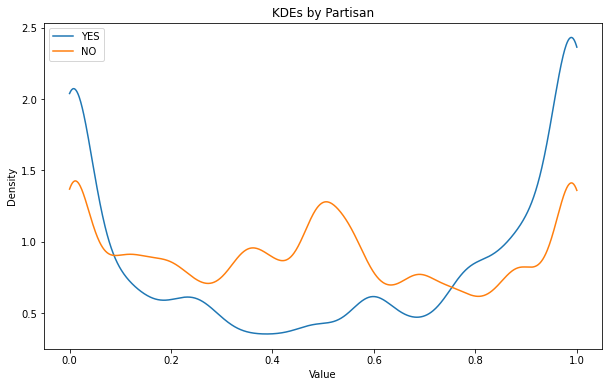

In [66]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def normalize_data(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

directory = "np_data_new"
df = pd.read_csv("median_voter_analysis.csv")
partisan_data = {'YES': [], 'NO': []}

for file in os.listdir(directory):
    try:
        filename = file[0:-4] + ".csv"
        if df.loc[df["filename"] == filename, "#candidates"].tolist()[0] > 2:
            data = np.load(os.path.join(directory, file))

            # Normalize the data
            data = normalize_data(data)

            partisan = df.loc[df["filename"] == filename, "partisan"].tolist()[0]
            if partisan in partisan_data:
                partisan_data[partisan].extend(data)  # Accumulate the normalized data

    except Exception as e:
        print(filename, " ", e)

# Calculate and plot KDEs for the accumulated data
plt.figure(figsize=(10, 6))

for key, data in partisan_data.items():
    if data:  # Check if there is data for the group
        kde = gaussian_kde(data, bw_method=0.1)
        x = np.linspace(np.min(data), np.max(data), 1000)
        kde_values = kde(x)
        plt.plot(x, kde_values, label=key)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('KDEs by Partisan')
plt.legend()
plt.show()


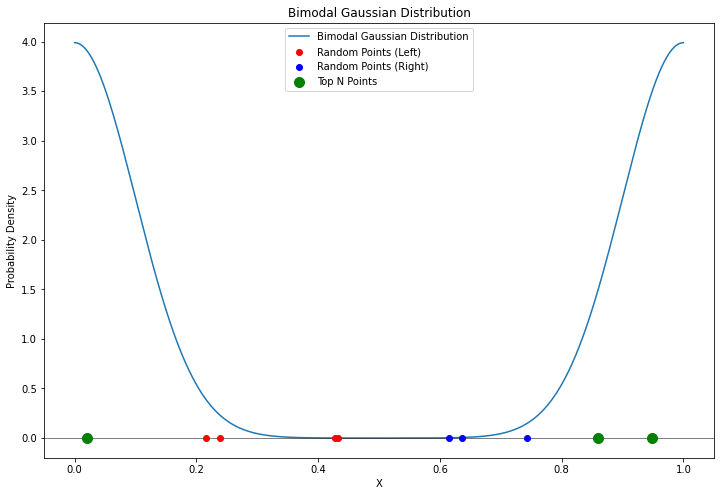

Top N Points: [0.85985986 0.94894895 0.02002002]
Top N Y-Values: [1.49433847 3.50200643 3.91027029]


In [100]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Step 1: Generate a Perfect Bimodal Gaussian
mu1, sigma1 = 0, 0.1
mu2, sigma2 = 1, 0.1
x = np.linspace(0, 1, 1000)
y1 = norm.pdf(x, mu1, sigma1)
y2 = norm.pdf(x, mu2, sigma2)
y = y1 + y2

plt.figure(figsize=(12, 8))

# Plot the bimodal distribution
plt.plot(x, y, label='Bimodal Gaussian Distribution')
plt.title('Bimodal Gaussian Distribution')
plt.xlabel('X')
plt.ylabel('Probability Density')

# Step 2: Divide the X-Axis into Two Halves
midpoint = len(x) // 2
x_left = x[:midpoint]
x_right = x[midpoint:]
y_left = y[:midpoint]
y_right = y[midpoint:]

# Step 3: Generate Random Points
#np.random.seed(0)  # For reproducibility
random_points_left = np.random.choice(x_left, 5, replace=False)
random_points_right = np.random.choice(x_right, 5, replace=False)


#random_points_left = np.append(random_points_left, 0)
#random_points_right = np.append(random_points_right, 1)

# Step 4: Calculate the Y-Values (Probability Density) at the Random Points
y_values_left = norm.pdf(random_points_left, mu1, sigma1) + norm.pdf(random_points_left, mu2, sigma2)
y_values_right = norm.pdf(random_points_right, mu1, sigma1) + norm.pdf(random_points_right, mu2, sigma2)

# Combine points and y-values
points = np.concatenate((random_points_left, random_points_right))
y_values = np.concatenate((y_values_left, y_values_right))

# Step 5: Select Top N Points
n = 3  # For example
top_n_indices = np.argsort(y_values)[-n:]
top_n_points = points[top_n_indices]
top_n_y_values = y_values[top_n_indices]

# Plot the selected random points on the x-axis
plt.axhline(0, color='black', linewidth=0.5)
plt.scatter(random_points_left, np.zeros_like(random_points_left), color='red', label='Random Points (Left)', zorder=5)
plt.scatter(random_points_right, np.zeros_like(random_points_right), color='blue', label='Random Points (Right)', zorder=5)
plt.scatter(top_n_points, np.zeros_like(top_n_points), color='green', s=100, label='Top N Points', zorder=5)
plt.legend()
plt.show()

print("Top N Points:", top_n_points)
print("Top N Y-Values:", top_n_y_values)


In [68]:
top_n_points = normalize_data(top_n_points)

Albany_11082022_FAKECityCouncil.csv   list index out of range


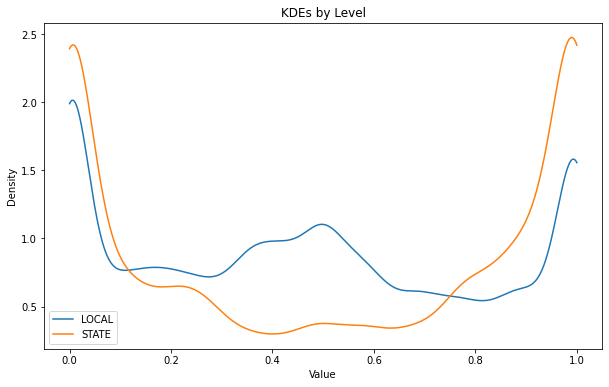

In [582]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def normalize_data(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

directory = "np_data_new"
df = pd.read_csv("median_voter_analysis2.csv")
level_data = {'LOCAL': [], 'STATE': []}

for file in os.listdir(directory):
    filename = file[0:-4] + ".csv"
    try:
        data = np.load(os.path.join(directory, file))
        data = normalize_data(data)

        filename = file[0:-4] + ".csv"
        level = df.loc[df["filename"] == filename, "level"].tolist()[0]
        if level == 'FEDERAL':
            level = 'STATE'
        if level in level_data:
            level_data[level].extend(data)  # Accumulate the normalized data

    except Exception as e:
        print(filename, " ", e)

# Calculate and plot KDEs for the accumulated data
plt.figure(figsize=(10, 6))

"""data_local = level_data['LOCAL']
kde = gaussian_kde(data, bw_method=0.1)
x_local = np.linspace(np.min(data), np.max(data), 1000)
kde_values_local = kde(x)
plt.plot(x_local, kde_values_local, label=key)"""
for key, data in level_data.items():
    if key == 'LOCAL' and data:  # Check if there is data for the group
        kde = gaussian_kde(data, bw_method=0.1)
        x = np.linspace(np.min(data), np.max(data), 1000)
        kde_values = kde(x)
        plt.plot(x, kde_values, label=key)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('KDEs by Level')
plt.legend()
plt.show()


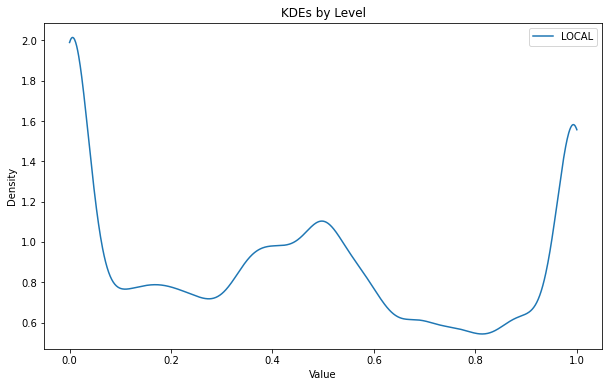

In [583]:
plt.figure(figsize=(10, 6))

"""data_local = level_data['LOCAL']
kde = gaussian_kde(data, bw_method=0.1)
x_local = np.linspace(np.min(data), np.max(data), 1000)
kde_values_local = kde(x)
plt.plot(x_local, kde_values_local, label=key)"""
for key, data in level_data.items():
    if key == 'LOCAL' and data:  # Check if there is data for the group
        kde = gaussian_kde(data, bw_method=0.1)
        x = np.linspace(np.min(data), np.max(data), 1000)
        kde_values = kde(x)
        plt.plot(x, kde_values, label=key)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('KDEs by Level')
plt.legend()
plt.show()

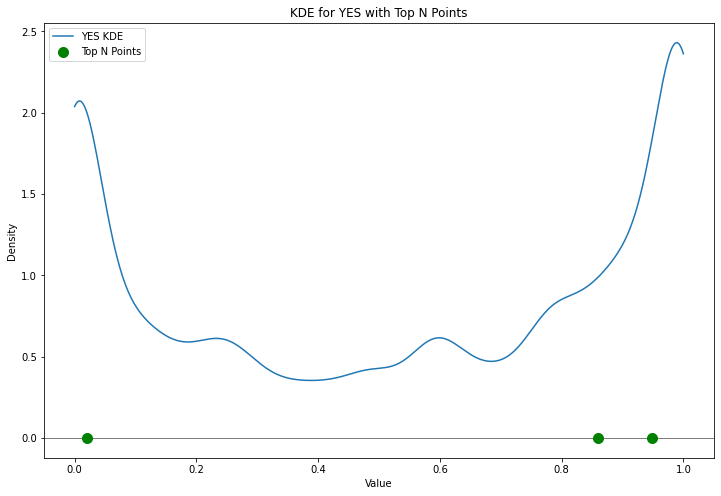

In [102]:
if partisan_data['YES']:
    kde_yes = gaussian_kde(partisan_data['YES'], bw_method=0.1)
    x_yes = np.linspace(np.min(partisan_data['YES']), np.max(partisan_data['YES']), 1000)
    kde_values_yes = kde_yes(x_yes)

    plt.figure(figsize=(12, 8))
    plt.plot(x_yes, kde_values_yes, label='YES KDE')
    plt.scatter(top_n_points, np.zeros_like(top_n_points), color='green', s=100, label='Top N Points', zorder=5)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.title('KDE for YES with Top N Points')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

In [542]:
kde_yes = gaussian_kde(partisan_data['YES'], bw_method=0.1)
x_yes = np.linspace(np.min(partisan_data['YES']), np.max(partisan_data['YES']), 1000)
kde_values_yes = kde_yes(x_yes)

In [556]:
kde_values = kde_values_yes / np.sum(kde_values)

# Compute the cumulative sum
cumulative_sum = np.cumsum(kde_values)

# Find the median
median_index = np.searchsorted(cumulative_sum, 0.5)
median_kde = x[median_index]

In [557]:
print(median_kde)

0.6956956956956957


In [554]:
cdf_yes = np.cumsum(kde_yes(x_yes)) * (x_yes[1] - x_yes[0])
median_index = np.argmin(np.abs(cdf_yes - 0.5))
median_value = x_yes[median_index]

In [555]:
print(median_value)

0.7757757757757757


In [549]:
mirrored_voter_data = 1 - voter_data
mirrored_voter_kde = gaussian_kde(mirrored_voter_data)
x_voter_mirrored = 1 - x_voter

TypeError: unsupported operand type(s) for -: 'int' and 'list'

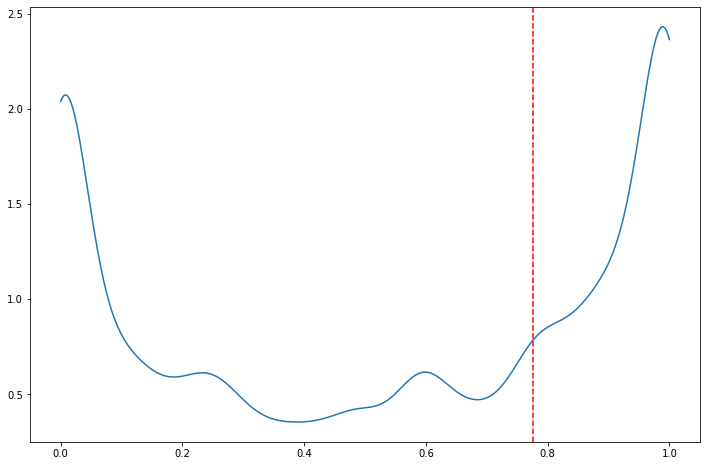

In [367]:
plt.figure(figsize=(12, 8))
plt.plot(x_yes, kde_values_yes, label='YES KDE')
plt.axvline(x=median_value, color='red', linestyle='--', label=f'Median Voter')

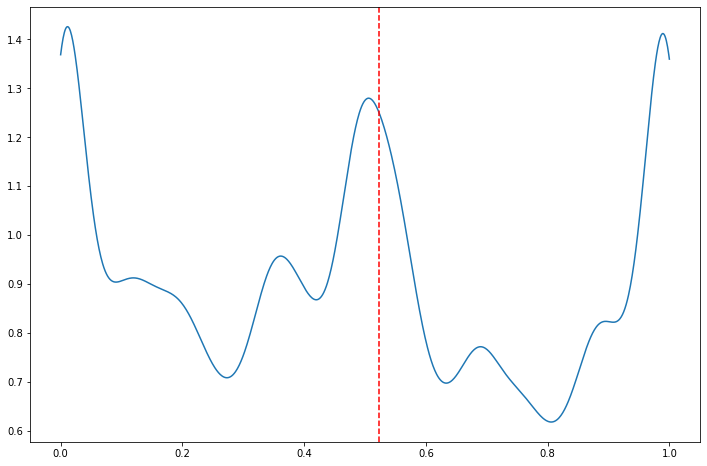

In [701]:
cdf_no = np.cumsum(kde_no(x_no)) * (x_no[1] - x_no[0])
median_index = np.argmin(np.abs(cdf_no - 0.5))
median_value = x_no[median_index]

plt.figure(figsize=(12, 8))
plt.plot(x_no, kde_values_no, label='Local')
plt.axvline(x=median_value, color='red', linestyle='--', label=f'Median Voter')

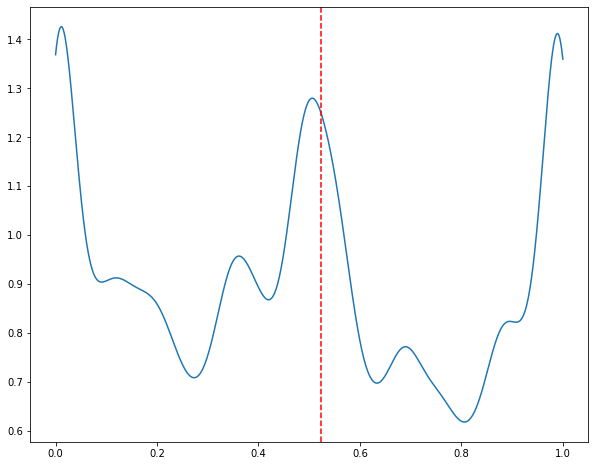

In [703]:
plt.figure(figsize=(10, 8))
plt.plot(x_no, kde_values_no, label='Local')
plt.axvline(x=median_value, color='red', linestyle='--', label=f'Median Voter')

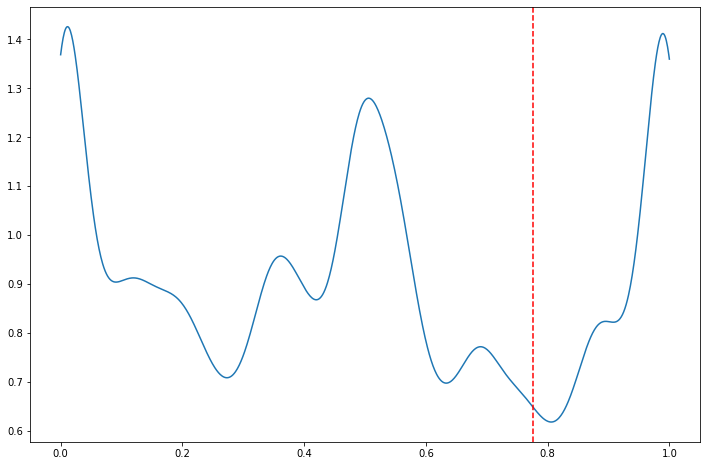

In [358]:
kde_no = gaussian_kde(partisan_data['NO'], bw_method=0.1)
x_no = np.linspace(np.min(partisan_data['NO']), np.max(partisan_data['NO']), 1000)
kde_values_no = kde_no(x_no)
cdf_no = np.cumsum(kde_no(x_no)) * (x_no[1] - x_no[0])
median_index_no = np.argmin(np.abs(cdf_no - 0.5))
median_value_no = x_no[median_index]
plt.figure(figsize=(12, 8))
plt.plot(x_no, kde_values_no, label='NO KDE')
plt.axvline(x=median_value, color='red', linestyle='--', label=f'Median Voter')

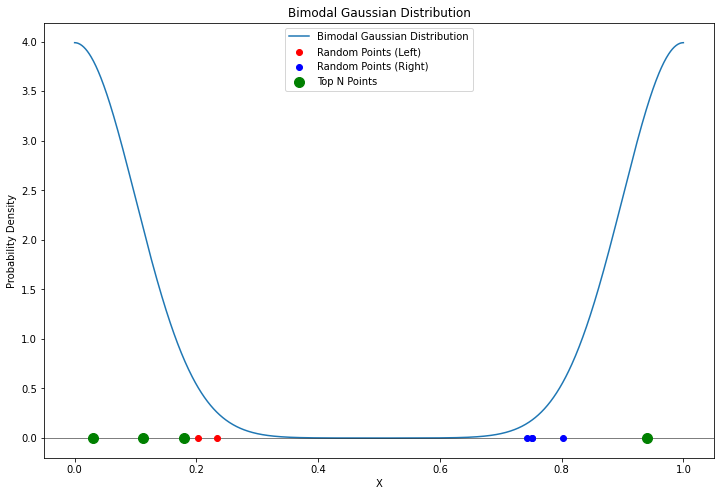

Top N Points: [0.17917918 0.11311311 0.93993994 0.03003003]
Top N Y-Values: [0.8012259  2.10416295 3.33104484 3.81353441]


In [159]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Step 1: Generate a Perfect Bimodal Gaussian
mu1, sigma1 = 0, 0.1
mu2, sigma2 = 1, 0.1
x = np.linspace(0, 1, 1000)
y1 = norm.pdf(x, mu1, sigma1)
y2 = norm.pdf(x, mu2, sigma2)
y = y1 + y2

plt.figure(figsize=(12, 8))

# Plot the bimodal distribution
plt.plot(x, y, label='Bimodal Gaussian Distribution')
plt.title('Bimodal Gaussian Distribution')
plt.xlabel('X')
plt.ylabel('Probability Density')

# Step 2: Divide the X-Axis into Two Halves
midpoint = len(x) // 2
x_left = x[:midpoint]
x_right = x[midpoint:]
y_left = y[:midpoint]
y_right = y[midpoint:]

# Step 3: Generate Random Points
#np.random.seed(0)  # For reproducibility
random_points_left = np.random.choice(x_left, 5, replace=False)
random_points_right = np.random.choice(x_right, 5, replace=False)


#random_points_left = np.append(random_points_left, 0)
#random_points_right = np.append(random_points_right, 1)

# Step 4: Calculate the Y-Values (Probability Density) at the Random Points
y_values_left = norm.pdf(random_points_left, mu1, sigma1) + norm.pdf(random_points_left, mu2, sigma2)
y_values_right = norm.pdf(random_points_right, mu1, sigma1) + norm.pdf(random_points_right, mu2, sigma2)

# Combine points and y-values
points = np.concatenate((random_points_left, random_points_right))
y_values = np.concatenate((y_values_left, y_values_right))

# Step 5: Select Top N Points
n = 4  # For example
top_n_indices = np.argsort(y_values)[-n:]
top_n_points = points[top_n_indices]
top_n_y_values = y_values[top_n_indices]

# Plot the selected random points on the x-axis
plt.axhline(0, color='black', linewidth=0.5)
plt.scatter(random_points_left, np.zeros_like(random_points_left), color='red', label='Random Points (Left)', zorder=5)
plt.scatter(random_points_right, np.zeros_like(random_points_right), color='blue', label='Random Points (Right)', zorder=5)
plt.scatter(top_n_points, np.zeros_like(top_n_points), color='green', s=100, label='Top N Points', zorder=5)
plt.legend()
plt.show()

print("Top N Points:", top_n_points)
print("Top N Y-Values:", top_n_y_values)




In [177]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

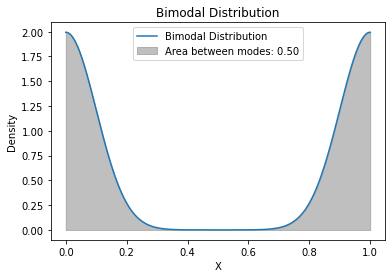

In [463]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize

# Define parameters
width1 = 0.1     # Width (standard deviation) of the first peak
width2 = 0.1     # Width (standard deviation) of the second peak
area_between = 0.9  # Desired area between the two peaks

# Means of the peaks
mean1 = 0
mean2 = 1

# Create the distributions
dist1 = norm(loc=mean1, scale=width1)
dist2 = norm(loc=mean2, scale=width2)

# Define the mixture distribution
def mixture_distribution(x, height1, height2):
    return height1 * dist1.pdf(x) + height2 * dist2.pdf(x)

# Normalize the distribution
def normalize_distribution(x, height1, height2):
    total_area, _ = quad(lambda x: mixture_distribution(x, height1, height2), -np.inf, np.inf)
    return mixture_distribution(x, height1, height2) / total_area

# Define the area between the two modes
def area_between_modes(height1, height2):
    area, _ = quad(lambda x: normalize_distribution(x, height1, height2), mean1, mean2)
    return area

# Objective function to minimize
def objective_function(params):
    height1, height2 = params
    return abs(area_between_modes(height1, height2) - area_between)

# Initial guess for heights
initial_heights = [1, 1]

# Perform optimization
result = minimize(objective_function, initial_heights, bounds=[(0, None), (0, None)])

# Optimal heights
optimal_height1, optimal_height2 = result.x

# Define x values
x = np.linspace(0, 1, 1000)
y = normalize_distribution(x, optimal_height1, optimal_height2)

# Plot the mixture distribution
plt.plot(x, y, label='Bimodal Distribution')

# Calculate the area between the two modes with optimal heights
area_optimal_between_modes = area_between_modes(optimal_height1, optimal_height2)

plt.fill_between(x, 0, y, where=((x >= mean1) & (x <= mean2)), color='gray', alpha=0.5, label=f'Area between modes: {area_optimal_between_modes:.2f}')
plt.legend()
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Bimodal Distribution')
plt.show()

#print(f'Optimal heights: {optimal_height1:.2f}, {optimal_height2:.2f}')
#print(f'Area between the two modes: {area_optimal_between_modes:.2f}')


Sampled points:
From y1: 0.02702702702702703
From y2: 0.2042042042042042
From y3: 0.990990990990991


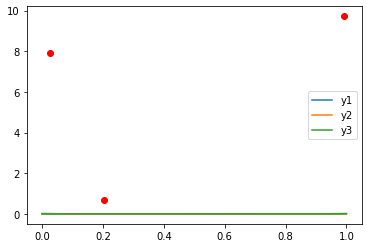

In [603]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Given parameters
mu1, sigma1 = 0, 0.04
mu2, sigma2 = 0.5, 0.2
mu3, sigma3 = 1, 0.04

# Create the x values
x_can = np.linspace(0, 1, 1000)

# Create the y values (PDFs)
y1 = norm.pdf(x_can, mu1, sigma1)
y2 = norm.pdf(x_can, mu2, sigma2)
y3 = norm.pdf(x_can, mu3, sigma3)

# Normalize the PDFs to form a valid probability density function
y1 /= y1.sum()
y2 /= y2.sum()
y3 /= y3.sum()

# Create cumulative distribution functions (CDFs)
cdf1 = np.cumsum(y1)
cdf2 = np.cumsum(y2)
cdf3 = np.cumsum(y3)

# Draw random samples from a uniform distribution
u1, u2, u3 = np.random.rand(3)

# Map the uniform samples to the distributions using the CDF
sample1 = x_can[np.searchsorted(cdf1, u1)]
sample2 = x_can[np.searchsorted(cdf2, u2)]
sample3 = x_can[np.searchsorted(cdf3, u3)]

# Display the results
print("Sampled points:")
print(f"From y1: {sample1}")
print(f"From y2: {sample2}")
print(f"From y3: {sample3}")

# Plot the distributions and the sampled points
plt.plot(x_can, y1, label='y1')
plt.plot(x_can, y2, label='y2')
plt.plot(x_can, y3, label='y3')
plt.scatter([sample1, sample2, sample3], [norm.pdf(sample1, mu1, sigma1), norm.pdf(sample2, mu2, sigma2), norm.pdf(sample3, mu3, sigma3)], color='red')
plt.legend()
plt.show()


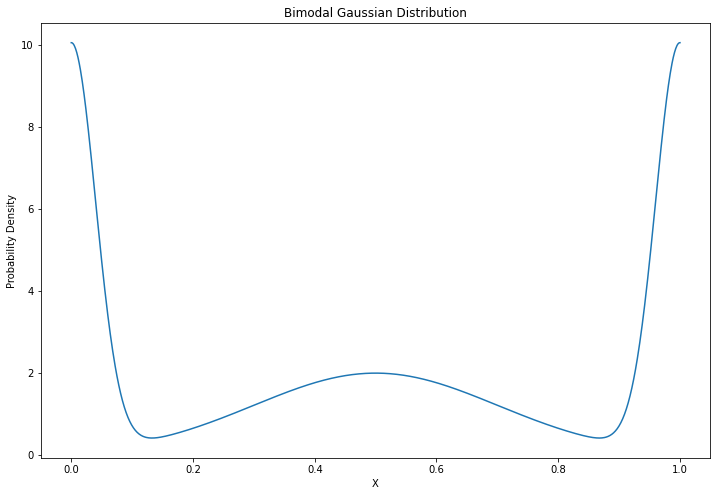

In [584]:
# Step 1: Generate a Perfect Bimodal Gaussian
mu1, sigma1 = 0, 0.04
mu2, sigma2 = 0.5, 0.2
mu3, sigma3 = 1, 0.04
x_can = np.linspace(0, 1, 1000)
y1 = norm.pdf(x, mu1, sigma1)
y2 = norm.pdf(x, mu2, sigma2)
y3 = norm.pdf(x, mu3, sigma3)
y_can = y1 + y2 + y3

plt.figure(figsize=(12, 8))

# Plot the bimodal distribution
plt.plot(x, y, label='Bimodal Gaussian Distribution')
plt.title('Bimodal Gaussian Distribution')
plt.xlabel('X')
plt.ylabel('Probability Density')

# Step 2: Divide the X-Axis into Two Halves
midpoint = len(x) // 2
x_left = x[:midpoint]
x_right = x[midpoint:]
y_left = y[:midpoint]
y_right = y[midpoint:]

In [473]:
# Step 2: Divide the X-Axis into Two Halves
midpoint = len(x) // 2
x_left = x[:midpoint]
x_right = x[midpoint:]
y_left = y[:midpoint]
y_right = y[midpoint:]

In [495]:
uni = np.linspace(0, 1, 1000)

In [591]:
def top_n_1(n, x_voter_plot, y_voter_plot, voter_dist, candidate_dist, visualize=True):
    x, y = candidate_dist
    midpoint = len(x) // 2
    x_left = x[:midpoint]
    x_right = x[midpoint:]
    y_left = y[:midpoint]
    y_right = y[midpoint:]

    random_points_left = np.random.choice(x_left, 5, replace=False)
    random_points_right = np.random.choice(x_right, 5, replace=False)

    mu1, sigma1, mu2, sigma2, mu3, sigma3 = 0, 0.1, 0.5, 0.1, 1, 0.1  # Example values for a hypothetical trimodal distribution
    y_values_left = norm.pdf(random_points_left, mu1, sigma1) + norm.pdf(random_points_left, mu2, sigma2) + norm.pdf(random_points_left, mu3, sigma3)
    y_values_right = norm.pdf(random_points_right, mu1, sigma1) + norm.pdf(random_points_right, mu2, sigma2) + norm.pdf(random_points_right, mu3, sigma3)

    points = np.concatenate((random_points_left, random_points_right))
    y_values = np.concatenate((y_values_left, y_values_right))

    top_n_indices = np.argsort(y_values)[-n:]
    top_n_points = points[top_n_indices]
    top_n_y_values = y_values[top_n_indices]

    top_left_index = np.argmax(y_values_left)
    top_right_index = np.argmax(y_values_right)
    #top_2_points = np.array([random_points_left[top_left_index], random_points_right[top_right_index]])

    top_2_indices = np.argsort(y_values)[-2:]
    top_2_points = points[top_2_indices]
    
    sampled_points = []
    while len(sampled_points) < 1000:
        new_samples = voter_dist.resample(1000).flatten()
        new_samples = new_samples[(new_samples >= 0) & (new_samples <= 1)]
        sampled_points.extend(new_samples)
    sampled_points = np.array(sampled_points[:1000])

    min_point = np.min(top_n_points)
    max_point = np.max(top_n_points)
    top_n_points_normalized = (top_n_points - min_point) / (max_point - min_point)

    ballot_counts = {}

    for point in sampled_points:
        distances = np.abs(top_n_points - point)
        sorted_indices = np.argsort(distances)
        ranking = tuple(top_n_points[sorted_indices])
        if ranking in ballot_counts:
            ballot_counts[ranking] += 1
        else:
            ballot_counts[ranking] = 1

    election = voting_rules(ballot_counts, top_n_points)
    irv_winner = election.irv()[0]
    condorcet_winner = election.condorcet()

    ballot_counts_top_2 = {}

    for point in sampled_points:
        distances = np.abs(top_2_points - point)
        sorted_indices = np.argsort(distances)
        ranking = tuple(top_2_points[sorted_indices])
        if ranking in ballot_counts_top_2:
            ballot_counts_top_2[ranking] += 1
        else:
            ballot_counts_top_2[ranking] = 1

    plurality_election = voting_rules(ballot_counts_top_2, top_2_points)
    #plurality_winner = plurality_election.plurality()

    top_2_y_values = [voter_dist.evaluate(point)[0] for point in top_2_points]
    plurality_winner = top_2_points[np.argmax(top_2_y_values)]

    if visualize:
        plt.figure(figsize=(12, 8))

        plt.subplot(2, 1, 1)
        plt.plot(x, y, label='Candidate Distribution')
        plt.scatter(random_points_left, np.zeros_like(random_points_left), color='blue', label='Random Points (Left)', zorder=5)
        plt.scatter(random_points_right, np.zeros_like(random_points_right), color='red', label='Random Points (Right)', zorder=5)
        plt.scatter(top_2_points, np.zeros_like(top_2_points), color='green', s=100, label='Top 2 Points', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), marker='x', color='green', s=100, label='Top N Points', zorder=5)
        plt.legend()
        plt.title('Candidate Distribution with Random Points and Top N Points')
        plt.xlabel('X')
        plt.ylabel('Probability Density')

        #x_voter_plot = np.linspace(0, 1, 1000)
        #y_voter_plot = voter_dist.evaluate(x_voter_plot)

        plt.subplot(2, 1, 2)
        plt.plot(x_voter_plot, y_voter_plot, label='Voter Distribution')
        plt.scatter(sampled_points, np.zeros_like(sampled_points), color='purple', label='Sampled Points from KDE', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), color='green', s=100, label='Top N Points', zorder=5)
        plt.scatter(irv_winner, 0, marker='o', color='yellow', s=100, label='IRV Winner', zorder=5)
        plt.scatter(plurality_winner, 0, marker='x', color='green', s=100, label='Plurality Winner', zorder=5)
        plt.scatter(condorcet_winner, 0, marker='*', color='red', s=100, label='Condorcet Winner', zorder=5)
        plt.axvline(x=np.median(sampled_points), color='red', linestyle='--', label='Median Voter')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.title('Voter Distribution with Sampled Points and Winners')
        plt.legend()

        plt.tight_layout()
        plt.show()


    return irv_winner, plurality_winner, condorcet_winner, top_n_points

In [633]:
def top_n(n, x_voter_plot, y_voter_plot, voter_dist, candidate_dist, visualize=True):
    x_can, y_can = candidate_dist

    # Select 10 random points from the candidate distribution based on their probability
    candidate_points = np.random.choice(x_can, size=10, p=y_can/y_can.sum(), replace=False)

    #round 1
    sampled_points_primary = []
    while len(sampled_points_primary) < 1000:
        new_samples = voter_dist.resample(1000).flatten()
        new_samples = new_samples[(new_samples >= 0) & (new_samples <= 1)]
        sampled_points_primary.extend(new_samples)
    sampled_points_primary = np.array(sampled_points_primary[:1000])   

    counts = np.zeros(len(candidate_points))
    for point in sampled_points_primary:
        closest_candidate_index = np.argmin(np.abs(candidate_points - point))
        counts[closest_candidate_index] += 1
    
    # Sort candidate points by their counts and select the top n
    top_n_indices = np.argsort(counts)[::-1][:n]
    top_n_points = candidate_points[top_n_indices]

    #round 2
    sampled_points = []
    while len(sampled_points) < 1000:
        new_samples = voter_dist.resample(1000).flatten()
        new_samples = new_samples[(new_samples >= 0) & (new_samples <= 1)]
        sampled_points.extend(new_samples)
    sampled_points = np.array(sampled_points[:1000])

    min_point = np.min(top_n_points)
    max_point = np.max(top_n_points)
    top_n_points_normalized = (top_n_points - min_point) / (max_point - min_point)

    ballot_counts = {}

    for point in sampled_points:
        distances = np.abs(top_n_points - point)
        sorted_indices = np.argsort(distances)
        ranking = tuple(top_n_points[sorted_indices])
        if ranking in ballot_counts:
            ballot_counts[ranking] += 1
        else:
            ballot_counts[ranking] = 1

    election = voting_rules(ballot_counts, top_n_points)
    irv_winner = election.irv()[0]
    condorcet_winner = election.condorcet()

    #plurality_election = voting_rules(ballot_counts_top_2, top_2_points)
    plurality_winner = election.plurality()


    if visualize:
        plt.figure(figsize=(12, 8))

        plt.subplot(2, 1, 1)
        plt.plot(x, y, label='Candidate Distribution')
        plt.scatter(candidate_points, np.zeros_like(candidate_points), color='blue', label='Random Candidates (10)', zorder=5)
        #plt.scatter(random_points_left, np.zeros_like(random_points_left), color='blue', label='Random Points (Left)', zorder=5)
        #plt.scatter(random_points_right, np.zeros_like(random_points_right), color='red', label='Random Points (Right)', zorder=5)
        #plt.scatter(top_2_points, np.zeros_like(top_2_points), color='green', s=100, label='Top 2 Points', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), marker='x', color='green', s=100, label='Top N Points', zorder=5)
        plt.legend()
        plt.title('Candidate Distribution with Random Points and Top N Points')
        plt.xlabel('X')
        plt.ylabel('Probability Density')

        #x_voter_plot = np.linspace(0, 1, 1000)
        #y_voter_plot = voter_dist.evaluate(x_voter_plot)

        plt.subplot(2, 1, 2)
        plt.plot(x_voter_plot, y_voter_plot, label='Voter Distribution')
        #plt.scatter(sampled_points, np.zeros_like(sampled_points), color='purple', label='Sampled Points from KDE', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), color='green', s=100, label='Top N Points', zorder=5)
        plt.scatter(irv_winner, 0, marker='o', color='yellow', s=100, label='IRV Winner', zorder=5)
        plt.scatter(plurality_winner, 0, marker='x', color='green', s=100, label='Plurality Winner', zorder=5)
        plt.scatter(condorcet_winner, 0, marker='*', color='red', s=100, label='Condorcet Winner', zorder=5)
        plt.axvline(x=np.median(sampled_points), color='red', linestyle='--', label='Median Voter')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.title('Voter Distribution with Sampled Points and Winners')
        plt.legend()

        plt.tight_layout()
        plt.show()


    return irv_winner, plurality_winner, condorcet_winner, top_n_points

[0.04904905 0.46346346 0.98398398]


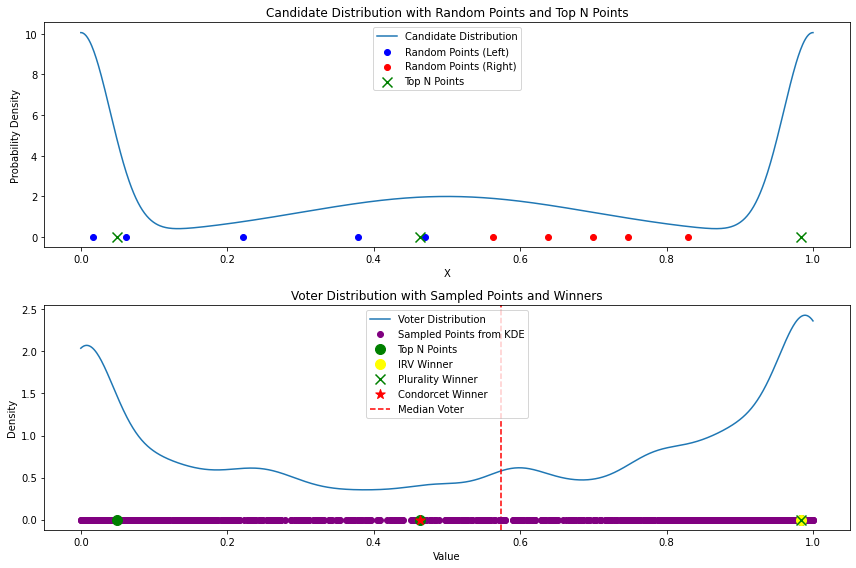

(0.983983983983984,
 0.983983983983984,
 0.46346346346346345,
 array([0.04904905, 0.46346346, 0.98398398]))

In [620]:

# Given parameters
mu1, sigma1 = 0, 0.04
mu2, sigma2 = 0.5, 0.2
mu3, sigma3 = 1, 0.04

# Create the x values
x_can = np.linspace(0, 1, 1000)

# Create the y values (PDFs)
y1 = norm.pdf(x_can, mu1, sigma1)
y2 = norm.pdf(x_can, mu2, sigma2)
y3 = norm.pdf(x_can, mu3, sigma3)
y_can = y1 + y2 + y3

# Normalize the PDFs to form a valid probability density function
y1 /= y1.sum()
y2 /= y2.sum()
y3 /= y3.sum()

# Create cumulative distribution functions (CDFs)
cdf1 = np.cumsum(y1)
cdf2 = np.cumsum(y2)
cdf3 = np.cumsum(y3)

# Draw random samples from a uniform distribution
u1, u2, u3 = np.random.rand(3)

# Map the uniform samples to the distributions using the CDF
sample1 = x_can[np.searchsorted(cdf1, u1)]
sample2 = x_can[np.searchsorted(cdf2, u2)]
sample3 = x_can[np.searchsorted(cdf3, u3)]
top_given_n(x_yes, kde_values_yes, kde_yes, [sample1, sample2, sample3])

In [704]:
def top_given_n(x_voter_plot, y_voter_plot, voter_dist, top_n_points, visualize=True):
    #top 3 candiates are given
    
    points = np.concatenate((random_points_left, random_points_right))
    y_values = np.concatenate((y_values_left, y_values_right))

    #top_n_indices = np.argsort(y_values)[-n:]
    #top_n_points = points[top_n_indices]
    top_n_y_values = y_values[top_n_indices]

    top_left_index = np.argmax(y_values_left)
    top_right_index = np.argmax(y_values_right)
    #top_2_points = np.array([random_points_left[top_left_index], random_points_right[top_right_index]])

    top_2_indices = np.argsort(y_values)[-2:]
    top_2_points = points[top_2_indices]
    
    sampled_points = []
    while len(sampled_points) < 1000:
        new_samples = voter_dist.resample(1000).flatten()
        new_samples = new_samples[(new_samples >= 0) & (new_samples <= 1)]
        sampled_points.extend(new_samples)
    sampled_points = np.array(sampled_points[:1000])

    min_point = np.min(top_n_points)
    max_point = np.max(top_n_points)
    top_n_points_normalized = (top_n_points - min_point) / (max_point - min_point)

    ballot_counts = {}
    top_n_points = np.array(top_n_points)
    
    for point in sampled_points:
        distances = np.abs(top_n_points - point)
        sorted_indices = np.argsort(distances)
        ranking = tuple(top_n_points[sorted_indices])
        if ranking in ballot_counts:
            ballot_counts[ranking] += 1
        else:
            ballot_counts[ranking] = 1

    election = voting_rules(ballot_counts, top_n_points)
    irv_winner = election.irv()[0]
    condorcet_winner = election.condorcet()

    ballot_counts_top_2 = {}

    """for point in sampled_points:
        distances = np.abs(top_2_points - point)
        sorted_indices = np.argsort(distances)
        ranking = tuple(top_2_points[sorted_indices])
        if ranking in ballot_counts_top_2:
            ballot_counts_top_2[ranking] += 1
        else:
            ballot_counts_top_2[ranking] = 1"""

    plurality_election = voting_rules(ballot_counts_top_2, top_2_points)
    #plurality_winner = plurality_election.plurality()

    top_2_y_values = [voter_dist.evaluate(point)[0] for point in top_2_points]
    plurality_winner = election.plurality()
    
    if visualize:
        plt.figure(figsize=(12, 8))

        plt.subplot(2, 1, 1)
        plt.plot(x, y, label='Candidate Distribution')
        plt.scatter(random_points_left, np.zeros_like(random_points_left), color='blue', label='Random Points (Left)', zorder=5)
        plt.scatter(random_points_right, np.zeros_like(random_points_right), color='red', label='Random Points (Right)', zorder=5)
        #plt.scatter(top_2_points, np.zeros_like(top_2_points), color='green', s=100, label='Top 2 Points', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), marker='x', color='green', s=100, label='Top N Points', zorder=5)
        plt.legend()
        plt.title('Candidate Distribution with Random Points and Top N Points')
        plt.xlabel('X')
        plt.ylabel('Probability Density')

        #x_voter_plot = np.linspace(0, 1, 1000)
        #y_voter_plot = voter_dist.evaluate(x_voter_plot)

        plt.subplot(2, 1, 2)
        plt.plot(x_voter_plot, y_voter_plot, label='Voter Distribution')
        plt.scatter(sampled_points, np.zeros_like(sampled_points), color='purple', label='Sampled Points from KDE', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), color='green', s=100, label='Top N Points', zorder=5)
        plt.scatter(irv_winner, 0, marker='o', color='yellow', s=100, label='IRV Winner', zorder=5)
        plt.scatter(plurality_winner, 0, marker='x', color='green', s=100, label='Plurality Winner', zorder=5)
        plt.scatter(condorcet_winner, 0, marker='*', color='red', s=100, label='Condorcet Winner', zorder=5)
        plt.axvline(x=np.median(sampled_points), color='red', linestyle='--', label='Median Voter')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.title('Voter Distribution with Sampled Points and Winners')
        plt.legend()

        plt.tight_layout()
        plt.show()


    return irv_winner, plurality_winner, condorcet_winner, top_n_points

In [504]:
mu1, sigma1 = 0, 0.1
mu2, sigma2 = 1, 0.1
x_voter = np.linspace(0, 1, 1000)
y1_voter = norm.pdf(x_voter, mu1, sigma1)
y2_voter = norm.pdf(x_voter, mu2, sigma2)
y_voter = y1_voter + y2_voter
voter_data = np.concatenate([np.random.normal(mu1, sigma1, 500), np.random.normal(mu2, sigma2, 500)])
voter_data = voter_data[(voter_data >= 0) & (voter_data <= 1)]
voter_kde = gaussian_kde(voter_data)

In [505]:
x_candidate = np.linspace(0, 1, 1000)
y_candidate = np.ones_like(x_candidate) / len(x_candidate)

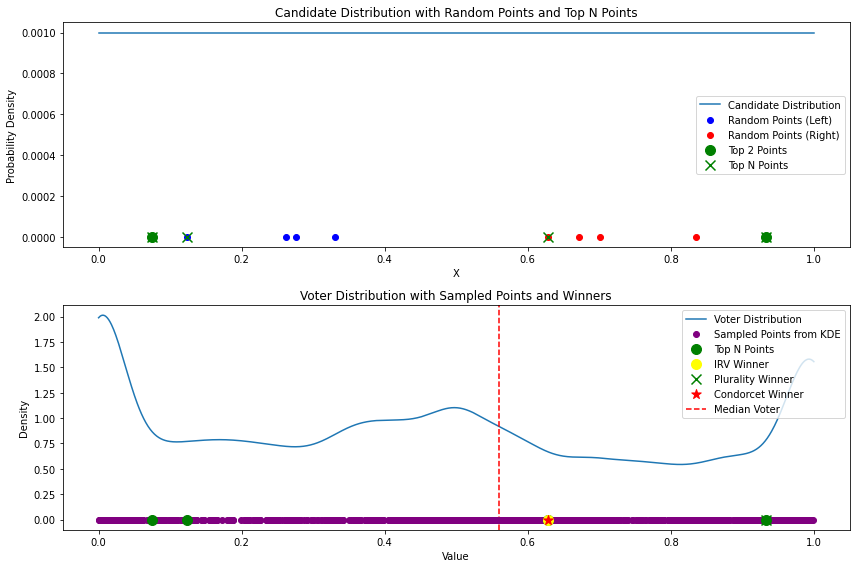

(0.6286286286286287,
 0.9329329329329329,
 0.6286286286286287,
 array([0.62862863, 0.12312312, 0.07507508, 0.93293293]))

In [587]:
mirrored_yes = 1 - np.array(level_data['LOCAL'])
mirrored_kde = gaussian_kde(mirrored_yes, bw_method=0.1)
x_yes_reversed = x[::-1]
kde_values_yes_reversed = kde_values[::-1]
top_n(4, x_yes_reversed, kde_values_yes_reversed, mirrored_kde, (x_candidate, y_candidate))


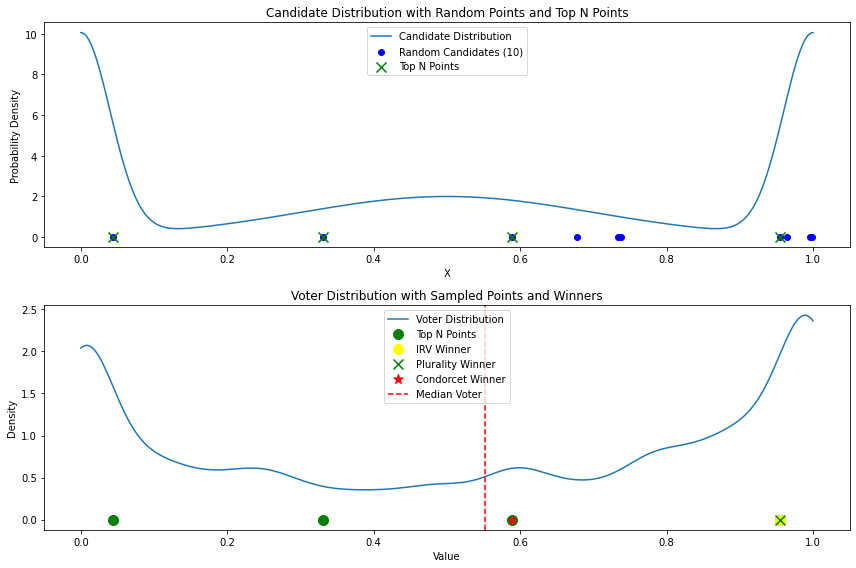

(0.954954954954955,
 0.954954954954955,
 0.5885885885885885,
 array([0.04404404, 0.95495495, 0.33133133, 0.58858859]))

In [644]:
# Given parameters
mu1, sigma1 = 0, 0.04
mu2, sigma2 = 0.5, 0.2
mu3, sigma3 = 1, 0.04

# Create the x values
x_can = np.linspace(0, 1, 1000)

# Create the y values (PDFs)
y1 = norm.pdf(x_can, mu1, sigma1)
y2 = norm.pdf(x_can, mu2, sigma2)
y3 = norm.pdf(x_can, mu3, sigma3)
y_can = y1 + y2 + y3
top_n(4, x_yes, kde_values_yes, kde_yes, (x_can, y_can), visualize=True)

In [672]:
def generate_and_group_permutations(items, choices):
    n = len(items)
    grouped_permutations = defaultdict(list)
    
    for i in range(1, choices + 1):
        for perm in permutations(items, i):
            grouped_permutations[perm[0]].append(perm)
    
    return grouped_permutations

In [673]:
perms = generate_and_group_permutations([1, 2, 3, 4], 4)
print(perms)

for point in perms:
    perms[point] = [b for b in perms[point] if is_consistent(b, {1: 1, 2: 2, 3: 3, 4: 4})==False]
print(perms)


defaultdict(<class 'list'>, {1: [(1,), (1, 2), (1, 3), (1, 4), (1, 2, 3), (1, 2, 4), (1, 3, 2), (1, 3, 4), (1, 4, 2), (1, 4, 3), (1, 2, 3, 4), (1, 2, 4, 3), (1, 3, 2, 4), (1, 3, 4, 2), (1, 4, 2, 3), (1, 4, 3, 2)], 2: [(2,), (2, 1), (2, 3), (2, 4), (2, 1, 3), (2, 1, 4), (2, 3, 1), (2, 3, 4), (2, 4, 1), (2, 4, 3), (2, 1, 3, 4), (2, 1, 4, 3), (2, 3, 1, 4), (2, 3, 4, 1), (2, 4, 1, 3), (2, 4, 3, 1)], 3: [(3,), (3, 1), (3, 2), (3, 4), (3, 1, 2), (3, 1, 4), (3, 2, 1), (3, 2, 4), (3, 4, 1), (3, 4, 2), (3, 1, 2, 4), (3, 1, 4, 2), (3, 2, 1, 4), (3, 2, 4, 1), (3, 4, 1, 2), (3, 4, 2, 1)], 4: [(4,), (4, 1), (4, 2), (4, 3), (4, 1, 2), (4, 1, 3), (4, 2, 1), (4, 2, 3), (4, 3, 1), (4, 3, 2), (4, 1, 2, 3), (4, 1, 3, 2), (4, 2, 1, 3), (4, 2, 3, 1), (4, 3, 1, 2), (4, 3, 2, 1)]})
defaultdict(<class 'list'>, {1: [(1, 3, 2), (1, 4, 2), (1, 4, 3), (1, 2, 4, 3), (1, 3, 2, 4), (1, 3, 4, 2), (1, 4, 2, 3), (1, 4, 3, 2)], 2: [(2, 4, 3), (2, 1, 4, 3), (2, 4, 1, 3), (2, 4, 3, 1)], 3: [(3, 1, 2), (3, 1, 2, 4), (3, 1,

In [734]:
def top_n_gamma(n, x_voter_plot, y_voter_plot, voter_dist, candidate_dist, visualize=True):
    # This function is the same as top_n, it just integrates gamma

    x_can, y_can = candidate_dist

    # Select 10 random points from the candidate distribution based on their probability
    candidate_points = np.random.choice(x_can, size=10, p=y_can/y_can.sum(), replace=False)


    df = pd.read_csv("median_voter_analysis.csv")
    
    # Filter the DataFrame for rows where #candidates equals n
    filtered_df = df[df['#candidates'] == n]
    
    # Extract the gamma values and convert to a NumPy array
    gamma_values = filtered_df['gamma'].to_numpy()
    # Draw a random number from the gamma values distribution
    random_gamma = np.random.choice(gamma_values)
  
    # Multiply by 1000 and round to the nearest integer
    consistent_voters = round(random_gamma * 1000)
    
    #round 1
    sampled_points_primary = []
    while len(sampled_points_primary) < 1000:
        new_samples = voter_dist.resample(1000).flatten()
        new_samples = new_samples[(new_samples >= 0) & (new_samples <= 1)]
        sampled_points_primary.extend(new_samples)
    sampled_points_primary = np.array(sampled_points_primary[:1000])   

    counts = np.zeros(len(candidate_points))
    for point in sampled_points_primary:
        closest_candidate_index = np.argmin(np.abs(candidate_points - point))
        counts[closest_candidate_index] += 1
    
    # Sort candidate points by their counts and select the top n
    top_n_indices = np.argsort(counts)[::-1][:n]
    top_n_points = candidate_points[top_n_indices]
    normalized_distances = {element: element for element in top_n_points}


    #round 2
    sampled_points = []
    while len(sampled_points) < consistent_voters:
        new_samples = voter_dist.resample(consistent_voters).flatten()
        new_samples = new_samples[(new_samples >= 0) & (new_samples <= 1)]
        sampled_points.extend(new_samples)
    sampled_points = np.array(sampled_points[:consistent_voters])

    min_point = np.min(top_n_points)
    max_point = np.max(top_n_points)
    top_n_points_normalized = (top_n_points - min_point) / (max_point - min_point)

    ballot_counts = {}

    for point in sampled_points:
        distances = np.abs(top_n_points - point)
        sorted_indices = np.argsort(distances)
        ranking = tuple(top_n_points[sorted_indices])
        if ranking in ballot_counts:
            ballot_counts[ranking] += 1
        else:
            ballot_counts[ranking] = 1

    perms = generate_and_group_permutations(top_n_points, n)

    for point in perms:
        perms[point] = [b for b in perms[point] if is_consistent(b, normalized_distances)==False]

    inconsistent_voters = 1000 - consistent_voters
    inconsistent_ballots_list = random.choices(perms, k=inconsistent_voters)

    sampled_points_inconsistet = []
    while len(sampled_points_inconsistet) < inconsistent_voters:
        new_samples = voter_dist.resample(inconsistent_voters).flatten()
        new_samples = new_samples[(new_samples >= 0) & (new_samples <= 1)]
        sampled_points_inconsistet.extend(new_samples)
    sampled_points_inconsistet = np.array(sampled_points_inconsistet[:inconsistent_voters])

    for point in sampled_points_inconsistet:
        distances = np.abs(top_n_points - point)
        min_index = np.argmin(distances)
        closest_point = top_n_points[min_index]
        ranking = random.choices(perms[closest_point], k=1)[0]
        
        if ranking not in ballot_counts:
            ballot_counts[ranking] = 0
        ballot_counts[ranking] += 1


    election = voting_rules(ballot_counts, top_n_points)
    irv_winner = election.irv()[0]
    condorcet_winner = election.condorcet()

    #plurality_election = voting_rules(ballot_counts_top_2, top_2_points)
    plurality_winner = election.plurality()
    first_place_support = election.get_first_place()

    if condorcet_winner == -1:
        first_place_support[condorcet_winner] = -1

    if visualize:
        plt.figure(figsize=(12, 8))

        #plt.subplot(2, 1, 1)
        plt.plot(x, y, label='Candidate Distribution')
        plt.scatter(candidate_points, np.zeros_like(candidate_points), color='blue', label='Random Candidates (10)', zorder=5)
        #plt.scatter(random_points_left, np.zeros_like(random_points_left), color='blue', label='Random Points (Left)', zorder=5)
        #plt.scatter(random_points_right, np.zeros_like(random_points_right), color='red', label='Random Points (Right)', zorder=5)
        #plt.scatter(top_2_points, np.zeros_like(top_2_points), color='green', s=100, label='Top 2 Points', zorder=5)
        plt.scatter(top_n_points, np.zeros_like(top_n_points), marker='x', color='green', s=100, label='Top N Points', zorder=5)
        plt.legend()
        plt.title('Candidate Distribution with Random Points and Top N Points')
        plt.xlabel('X')
        plt.ylabel('Probability Density')
        plt.show()
        plt.close()
        #x_voter_plot = np.linspace(0, 1, 1000)
        #y_voter_plot = voter_dist.evaluate(x_voter_plot)

        #plt.subplot(2, 1, 2)
        plt.figure(figsize=(12, 8))
        plt.plot(x_voter_plot, y_voter_plot, label='Voter Distribution')
        #plt.scatter(sampled_points, np.zeros_like(sampled_points), color='purple', label='Sampled Points from KDE', zorder=5)
        #plt.scatter(top_n_points, np.zeros_like(top_n_points), color='green', s=100, label='Top N Points', zorder=5)
        #plt.scatter(irv_winner, 0, marker='o', color='yellow', s=100, label='IRV Winner', zorder=5)
        #plt.scatter(plurality_winner, 0, marker='x', color='green', s=100, label='Plurality Winner', zorder=5)
        #plt.scatter(condorcet_winner, 0, marker='*', color='red', s=100, label='Condorcet Winner', zorder=5)
        plt.axvline(x=np.median(sampled_points), color='red', linestyle='--', label='Median Voter')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.title('Voter Distribution with Sampled Points and Winners')
        plt.legend()

        plt.tight_layout()
        plt.show()


    return irv_winner, plurality_winner, condorcet_winner, top_n_points, random_gamma, first_place_support[condorcet_winner], first_place_support[irv_winner], first_place_support[plurality_winner]

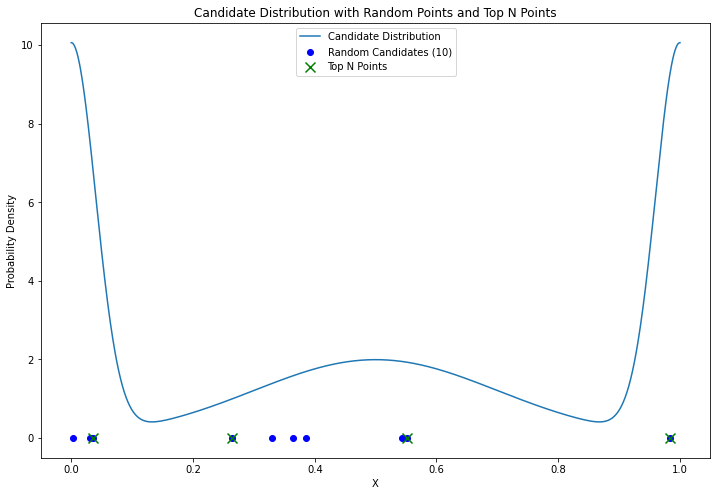

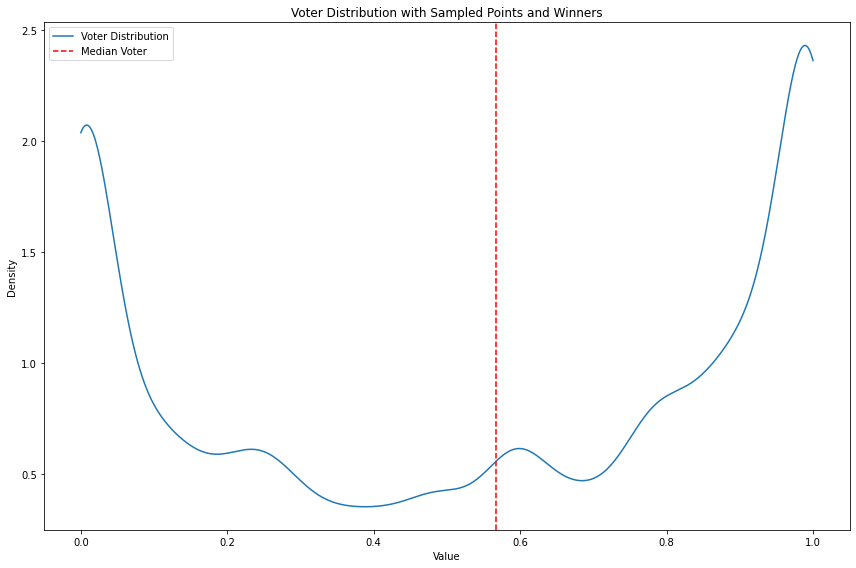

(0.9829829829829829,
 0.9829829829829829,
 0.5515515515515516,
 array([0.98298298, 0.55155155, 0.03603604, 0.26426426]),
 0.84234171,
 238,
 350,
 350)

In [722]:
# Given parameters
mu1, sigma1 = 0, 0.04
mu2, sigma2 = 0.5, 0.2
mu3, sigma3 = 1, 0.04

# Create the x values
x_can = np.linspace(0, 1, 1000)

# Create the y values (PDFs)
y1 = norm.pdf(x_can, mu1, sigma1)
y2 = norm.pdf(x_can, mu2, sigma2)
y3 = norm.pdf(x_can, mu3, sigma3)
y_can = y1 + y2 + y3
top_n_gamma(4, x_yes, kde_values_yes, kde_yes, (x_can, y_can), visualize=True)

In [659]:
num_runs = 1000
irv_winners = []
plurality_winners = []
condorcet_winners = []
top_n_points_list = []

for i in range(num_runs):
    # Draw random samples from a uniform distribution
    u1, u2, u3 = np.random.rand(3)

    # Map the uniform samples to the distributions using the CDF
    sample1 = x_can[np.searchsorted(cdf1, u1)]
    sample2 = x_can[np.searchsorted(cdf2, u2)]
    sample3 = x_can[np.searchsorted(cdf3, u3)]
    if i % 2 == 0:
        irv_winner, plurality_winner, condorcet_winner, top_n_points = top_given_n(x, kde_values, kde, [sample1, sample2, sample3], visualize=False)
        #irv_winner, plurality_winner, condorcet_winner, top_n_points = top_n(4, x, kde_values, kde, (x_can, y_can), visualize=False)
    else:
        mirrored_yes = 1 - np.array(level_data['LOCAL'])
        mirrored_kde = gaussian_kde(mirrored_yes, bw_method=0.1)
        x_yes_reversed = x[::-1]
        kde_values_yes_reversed = kde_values[::-1]
        irv_winner, plurality_winner, condorcet_winner, top_n_points = top_given_n(x_yes_reversed, kde_values_yes_reversed, mirrored_kde, [sample1, sample2, sample3], visualize=False)
    irv_winners.append(irv_winner)
    plurality_winners.append(plurality_winner)
    if condorcet_winner != -1:
        condorcet_winners.append(condorcet_winner)
    top_n_points_list.extend(top_n_points)



KeyboardInterrupt: 

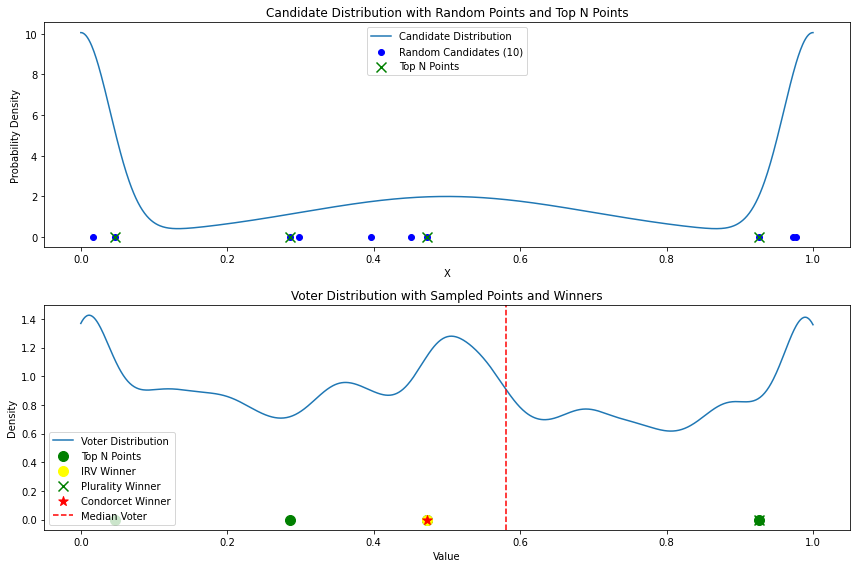

In [698]:
mirrored_no = 1 - np.array(level_data['LOCAL'])
mirrored_kde = gaussian_kde(mirrored_no, bw_method=0.1)
x_no_reversed = x_no[::-1]
kde_values_no_reversed = kde_values_no[::-1]
irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma = top_n_gamma(4, x_no_reversed, kde_values_no_reversed, mirrored_kde, (x, y), visualize=True)

In [699]:
num_runs = 1000
irv_winners = []
plurality_winners = []
condorcet_winners = []
top_n_points_list = []
gamma_values = []

for i in range(num_runs):
    if i % 2 == 0:
        irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma = top_n_gamma(4, x_no, kde_values_no, kde_no, (x_can, y_can), visualize=False)
    else:
        mirrored_no = 1 - np.array(level_data['LOCAL'])
        mirrored_kde = gaussian_kde(mirrored_no, bw_method=0.1)
        x_no_reversed = x_no[::-1]
        kde_values_no_reversed = kde_values_no[::-1]
        irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma = top_n_gamma(4, x_no_reversed, kde_values_no_reversed, mirrored_kde, (x, y), visualize=False)
    irv_winners.append(irv_winner)
    plurality_winners.append(plurality_winner)
    gamma_values.append(gamma)
    if condorcet_winner != -1:
        condorcet_winners.append(condorcet_winner)
    top_n_points_list.extend(top_n_points)

In [735]:
num_runs = 1000
irv_winners = []
plurality_winners = []
condorcet_winners = []
top_n_points_list = []
gamma_values = []
condorcet_support = []
irv_support = []
plurality_support = []


for i in range(num_runs):
    if i % 2 == 0:
        irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, condorcet, irv, plurality = top_n_gamma(4, x_no, kde_values_no, kde_no, (x_can, y_can), visualize=False)
    else:
        mirrored_no = 1 - np.array(level_data['LOCAL'])
        mirrored_kde = gaussian_kde(mirrored_no, bw_method=0.1)
        x_no_reversed = x_no[::-1]
        kde_values_no_reversed = kde_values_no[::-1]
        irv_winner, plurality_winner, condorcet_winner, top_n_points, gamma, condorcet, irv, plurality = top_n_gamma(4, x_no_reversed, kde_values_no_reversed, mirrored_kde, (x, y), visualize=False)
    irv_winners.append(irv_winner)
    plurality_winners.append(plurality_winner)
    gamma_values.append(gamma)
    condorcet_support.append(condorcet)
    irv_support.append(irv)
    plurality_support.append(plurality)
    if condorcet_winner != -1:
        condorcet_winners.append(condorcet_winner)
    top_n_points_list.extend(top_n_points)


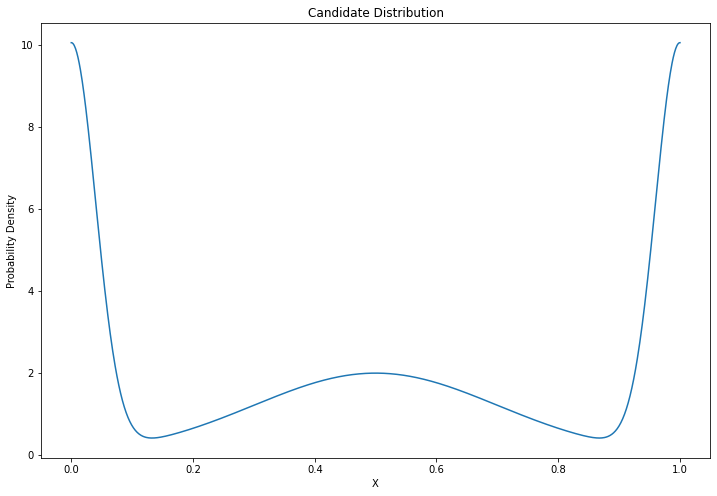

In [667]:
plt.figure(figsize=(12, 8))
plt.plot(x_can, y_can, label='Candidate Distribution')
plt.title('Candidate Distribution')
plt.xlabel('X')
plt.ylabel('Probability Density')
plt.show()

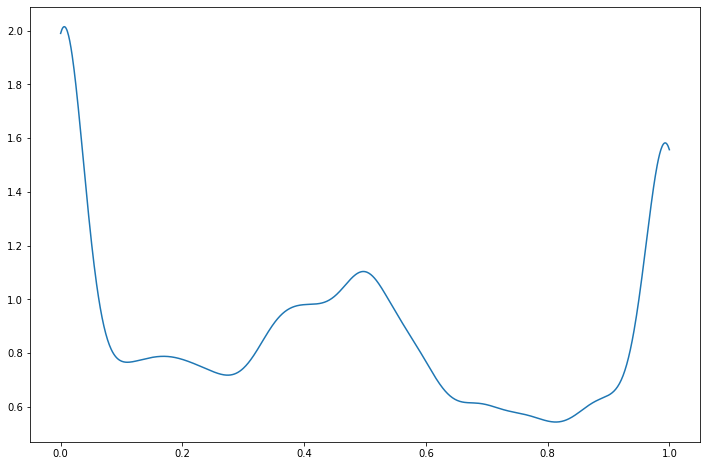

In [630]:
plt.figure(figsize=(12, 8))
plt.plot(x, kde_values, label='Voter Distribution')
plt.show()

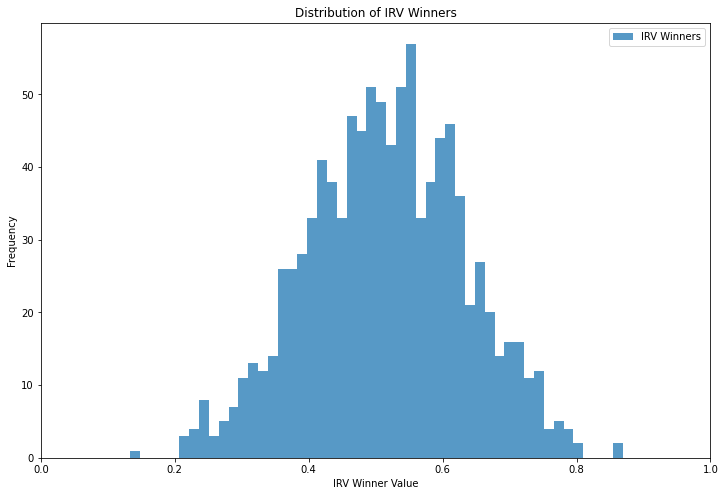

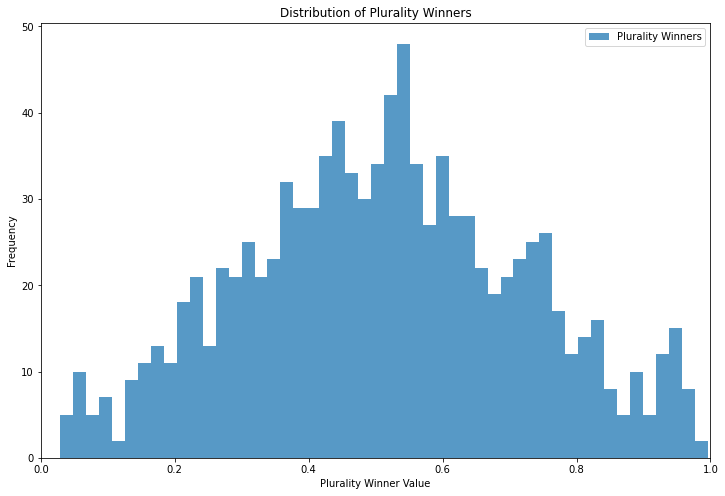

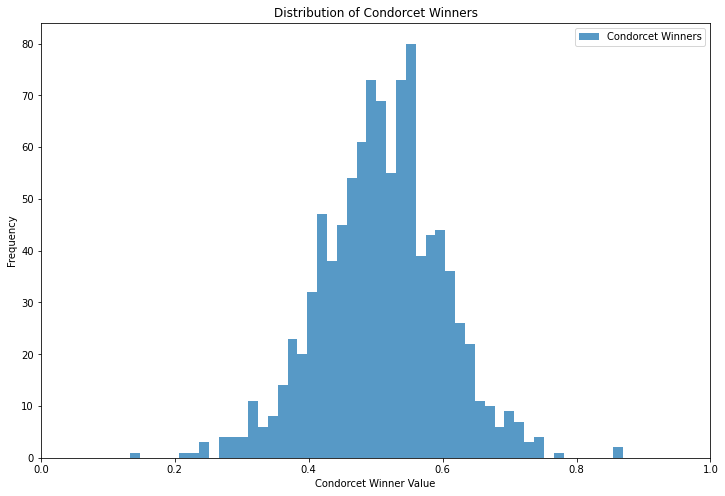

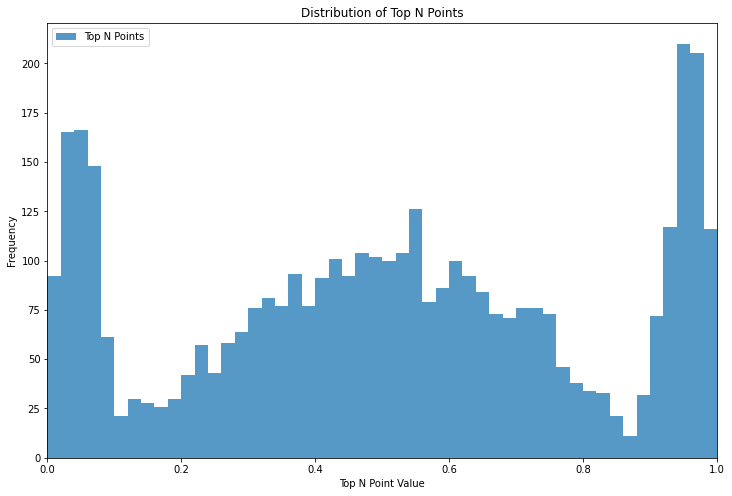

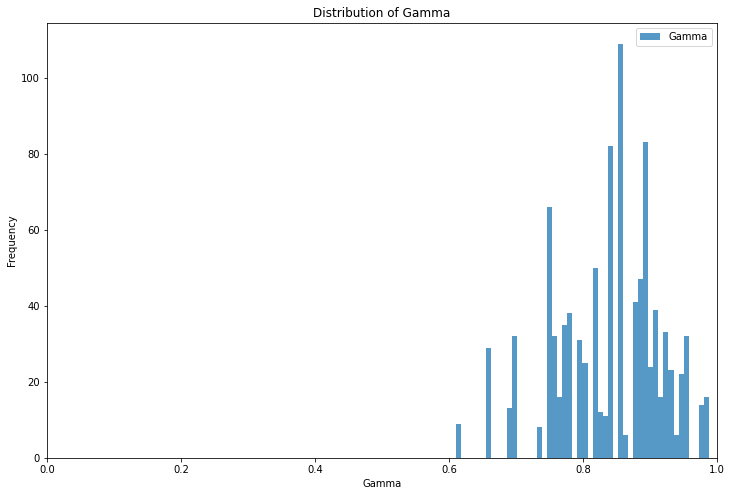

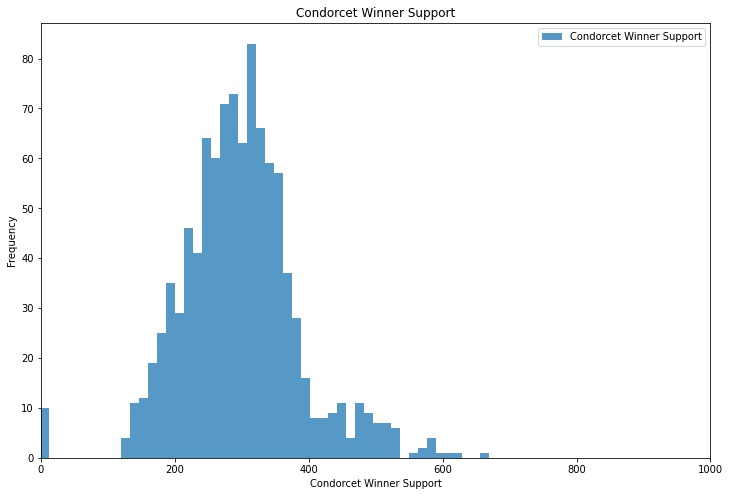

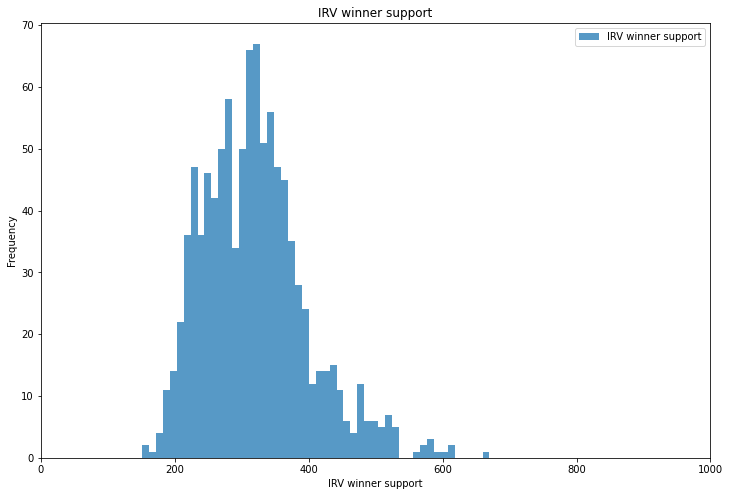

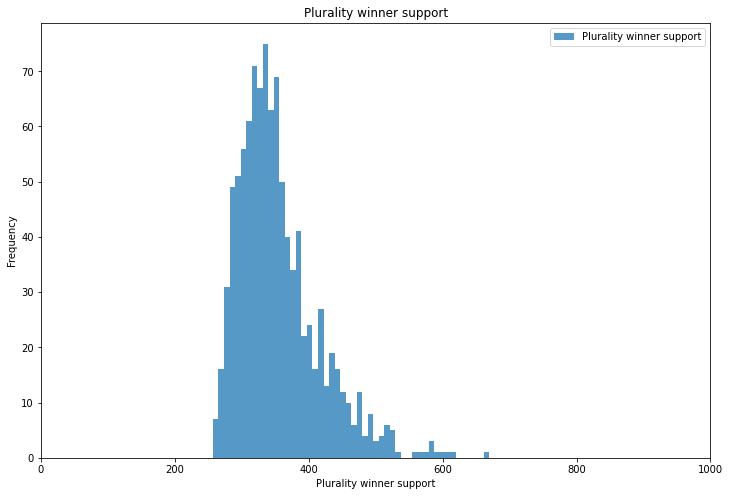

In [736]:
# Plot IRV winners
plt.figure(figsize=(12, 8))
plt.hist(irv_winners, bins=50, alpha=0.75, label='IRV Winners')
plt.xlabel('IRV Winner Value')
plt.ylabel('Frequency')
plt.xlim(0, 1) 
plt.title('Distribution of IRV Winners')
plt.legend()
plt.show()

# Plot Plurality winners
plt.figure(figsize=(12, 8))
plt.hist(plurality_winners, bins=50, alpha=0.75, label='Plurality Winners')
plt.xlabel('Plurality Winner Value')
plt.ylabel('Frequency')
plt.xlim(0, 1) 
plt.title('Distribution of Plurality Winners')
plt.legend()
plt.show()

# Plot Condorcet winners
plt.figure(figsize=(12, 8))
plt.hist(condorcet_winners, bins=50, alpha=0.75, label='Condorcet Winners')
plt.xlabel('Condorcet Winner Value')
plt.ylabel('Frequency')
plt.xlim(0, 1) 
plt.title('Distribution of Condorcet Winners')
plt.legend()
plt.show()

# Plot distribution of top 2 points
plt.figure(figsize=(12, 8))
plt.hist(top_n_points_list, bins=50, alpha=0.75, label='Top N Points')
plt.xlabel('Top N Point Value')
plt.ylabel('Frequency')
plt.xlim(0, 1) 
plt.title('Distribution of Top N Points')
plt.legend()
plt.show()

# Plot distribution of gamma
plt.figure(figsize=(12, 8))
plt.hist(gamma_values, bins=50, alpha=0.75, label='Gamma')
plt.xlabel('Gamma')
plt.ylabel('Frequency')
plt.xlim(0, 1) 
plt.title('Distribution of Gamma')
plt.legend()
plt.show()

# Plot distribution of c-s
plt.figure(figsize=(12, 8))
plt.hist(condorcet_support, bins=50, alpha=0.75, label='Condorcet Winner Support')
plt.xlabel('Condorcet Winner Support')
plt.ylabel('Frequency')
plt.xlim(0, 1000) 
plt.title('Condorcet Winner Support')
plt.legend()
plt.show()

# Plot distribution of irv-s
plt.figure(figsize=(12, 8))
plt.hist(irv_support, bins=50, alpha=0.75, label='IRV winner support')
plt.xlabel('IRV winner support')
plt.ylabel('Frequency')
plt.xlim(0, 1000) 
plt.title('IRV winner support')
plt.legend()
plt.show()

# Plot distribution of p-s
plt.figure(figsize=(12, 8))
plt.hist(plurality_support, bins=50, alpha=0.75, label='Plurality winner support')
plt.xlabel('Plurality winner support')
plt.ylabel('Frequency')
plt.xlim(0, 1000) 
plt.title('Plurality winner support')
plt.legend()
plt.show()


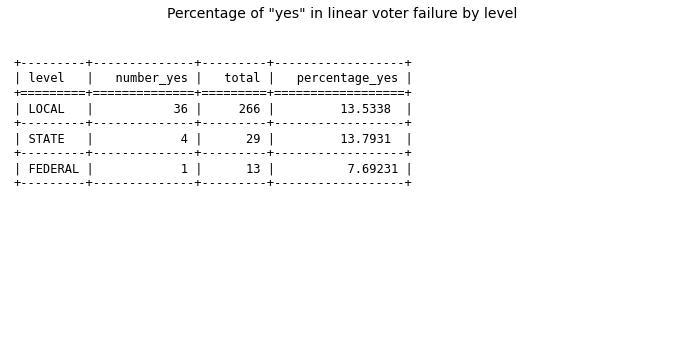

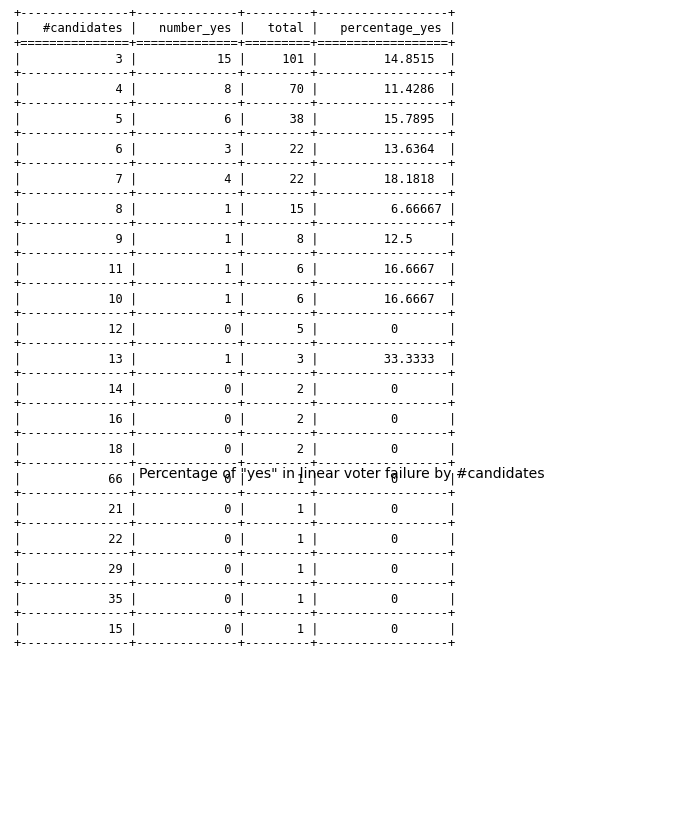

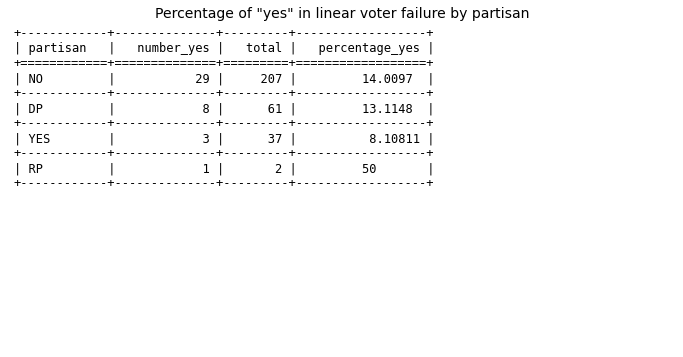

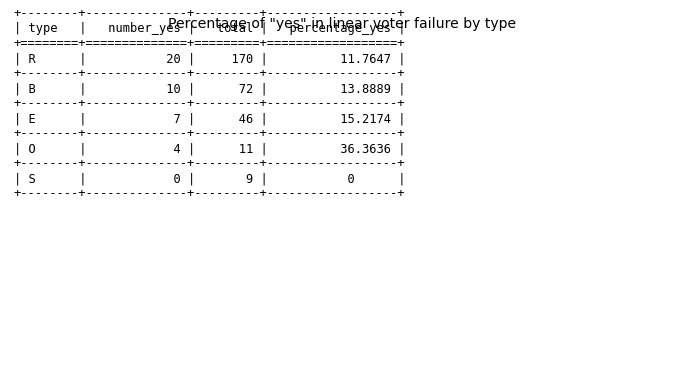

In [ ]:
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
import io

# Load the CSV file
df = pd.read_csv('median_voter_analysis.csv')
df = df[df['#candidates'] > 2]

# Define a function to calculate and plot percentages with totals and number of 'yes'
def plot_percentage_table(df, column, output_file):
    # Calculate the counts and percentages
    counts = df[df['linear voters failure'] == 'yes'][column].value_counts()
    total_counts = df[column].value_counts()
    
    # Align indices and fill missing values with 0
    counts = counts.reindex(total_counts.index, fill_value=0)
    percentage_yes = (counts / total_counts) * 100

    # Create the DataFrame
    data = pd.DataFrame({
        column: counts.index,
        'number_yes': counts.values,
        'total': total_counts.values,
        'percentage_yes': percentage_yes.values
    }).fillna(0)  # Fill NaN with 0 for categories with no 'yes'

    # Create a table using tabulate
    table_str = tabulate(data, headers='keys', tablefmt='grid', showindex=False)

    # Save the table as an image
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('off')
    plt.text(0.01, 0.5, table_str, {'family': 'monospace'}, fontsize=12)
    plt.title(f'Percentage of "yes" in linear voter failure by {column}', fontsize=14)
    #plt.savefig(output_file, bbox_inches='tight', pad_inches=0.1)
    plt.show()
    plt.close()

# Plot and save the tables for 'level', '#candidates', 'partisan', and 'type'
plot_percentage_table(df, 'level', 'level_percentage_table.png')
plot_percentage_table(df, '#candidates', 'candidates_percentage_table.png')
plot_percentage_table(df, 'partisan', 'partisan_percentage_table.png')
plot_percentage_table(df, 'type', 'type_percentage_table.png')


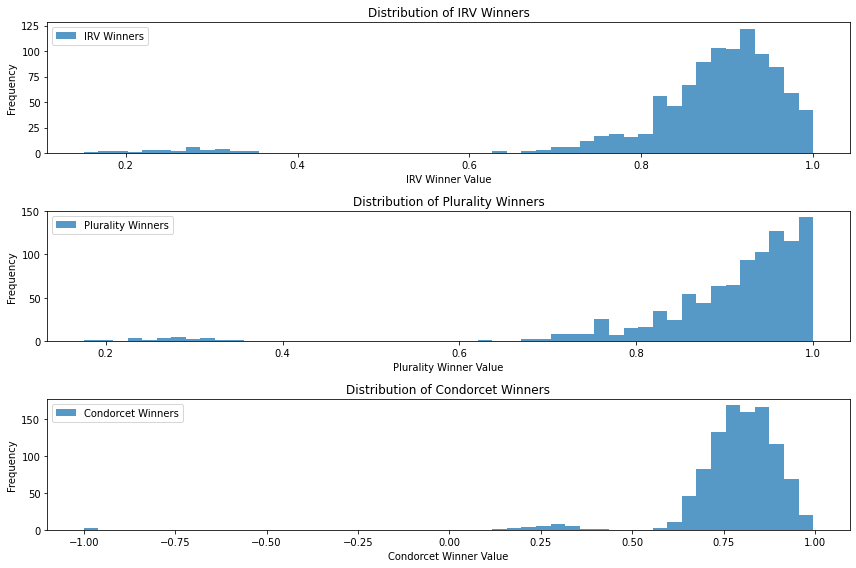

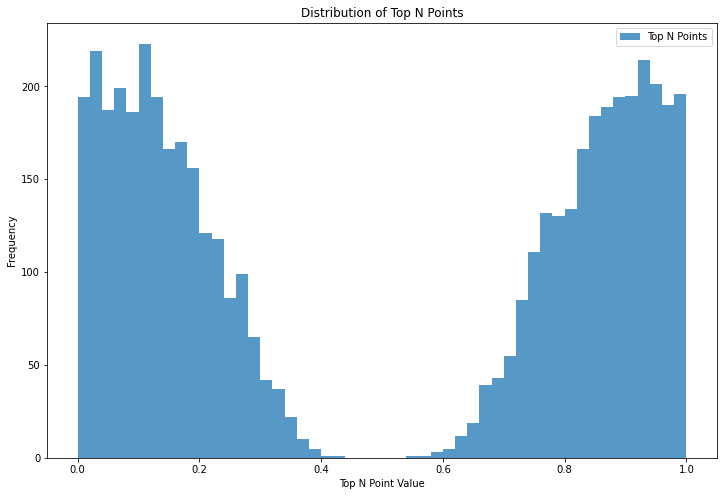

In [356]:
num_runs = 1000
irv_winners = []
plurality_winners = []
condorcet_winners = []
top_n_points_list = []

for _ in range(num_runs):
    irv_winner, plurality_winner, condorcet_winner, top_n_points = top_n(5)
    irv_winners.append(irv_winner)
    plurality_winners.append(plurality_winner)
    condorcet_winners.append(condorcet_winner)
    top_n_points_list.extend(top_n_points)


plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.hist(irv_winners, bins=50, alpha=0.75, label='IRV Winners')
plt.xlabel('IRV Winner Value')
plt.ylabel('Frequency')
plt.title('Distribution of IRV Winners')
plt.legend()

plt.subplot(3, 1, 2)
plt.hist(plurality_winners, bins=50, alpha=0.75, label='Plurality Winners')
plt.xlabel('Plurality Winner Value')
plt.ylabel('Frequency')
plt.title('Distribution of Plurality Winners')
plt.legend()

plt.subplot(3, 1, 3)
plt.hist(condorcet_winners, bins=50, alpha=0.75, label='Condorcet Winners')
plt.xlabel('Condorcet Winner Value')
plt.ylabel('Frequency')
plt.title('Distribution of Condorcet Winners')
plt.legend()

plt.tight_layout()
plt.show()

# Plot distribution of top_n_points
plt.figure(figsize=(12, 8))
plt.hist(top_n_points_list, bins=50, alpha=0.75, label='Top N Points')
plt.xlabel('Top N Point Value')
plt.ylabel('Frequency')
plt.title('Distribution of Top N Points')
plt.legend()
plt.show()